### LLM BARD

In [259]:
import pandas as pd

df = pd.read_csv('../data/datasets/redmi6.csv', encoding='windows-1252')

In [2]:
df.sample(10)

,Review Title,Customer name,Rating,Date,Category,Comments,Useful
206,Good,Raj kumar,5.0 out of 5 stars,on 20 September 2018,Others,Good,NaN
114,Good,Amazon Customer,5.0 out of 5 stars,on 22 September 2018,Others,Good,NaN
176,Best,Vinayak shinde,5.0 out of 5 stars,on 29 September 2018,Others,Best for price,NaN
185,Good,Amazon Customer,4.0 out of 5 stars,on 22 September 2018,Others,Good,NaN
256,It Hangs,Ranjeet,1.0 out of 5 stars,on 1 October 2018,Others,"After using it for 10 days, I am writing it, t...",NaN
9,All youtubers are paid,Sharad,5.0 out of 5 stars,on 22 September 2018,Others,Realme is sub brand of oppo\r\nHe give money t...,2 people found this helpful
132,Sound speaker is not working,Janardhan,1.0 out of 5 stars,on 22 September 2018,Others,Out of 2 only 1 speaker is working from day 1,NaN
175,Value of money,Ahir Dipak Ram,4.0 out of 5 stars,on 20 September 2018,Others,Superb product,NaN
218,Worst front camera on a Mi device till date.,Ram Rajkishore,1.0 out of 5 stars,on 15 September 2018,Camera,It has a worst front camera I have ever seen o...,NaN
42,Good,rajkumar kumawat,4.0 out of 5 stars,on 29 September 2018,Others,Good,One person found this helpful


### Anonymous vs Named

In [267]:
# Tampilkan 5 baris pertama dan kolom penting saja
print(anonymous_comments[['Review Title', 'Rating', 'Comments']].head())

# Atau hanya preview 50 karakter pertama dari komentar
anonymous_comments['Comments_preview'] = anonymous_comments['Comments'].str[:50]
print(anonymous_comments[['Review Title', 'Rating', 'Comments']].head())


       Review Title              Rating  \
3   Value for Money  5.0 out of 5 stars   
7         Fantastic  4.0 out of 5 stars   
8              Good  5.0 out of 5 stars   
13  Value for Money  5.0 out of 5 stars   
17        Fantastic  4.0 out of 5 stars   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

C:\Users\72531\AppData\Local\Temp\ipykernel_288\239636583.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anonymous_comments['Comments_preview'] = anonymous_comments['Comments'].str[:50]


In [4]:
# Ambil rating angka
df["Rating_value"] = df["Rating"].str.extract(r"(\d\.\d)").astype(float)

# Identifikasi Anonymous vs Named
df["Reviewer_Type"] = df["Customer name"].apply(lambda x: "Anonymous" if "Amazon Customer" in str(x) else "Named")

# Hitung distribusi
reviewer_dist = df["Reviewer_Type"].value_counts(normalize=True) * 100
print("Distribusi Reviewer:\n", reviewer_dist)

# Rata-rata rating
avg_rating = df.groupby("Reviewer_Type")["Rating_value"].mean()
print("\nRata-rata rating per reviewer type:\n", avg_rating)


Distribusi Reviewer:
 Reviewer_Type
Named        84.285714
Anonymous    15.714286
Name: proportion, dtype: float64

Rata-rata rating per reviewer type:
 Reviewer_Type
Anonymous    4.090909
Named        3.885593
Name: Rating_value, dtype: float64


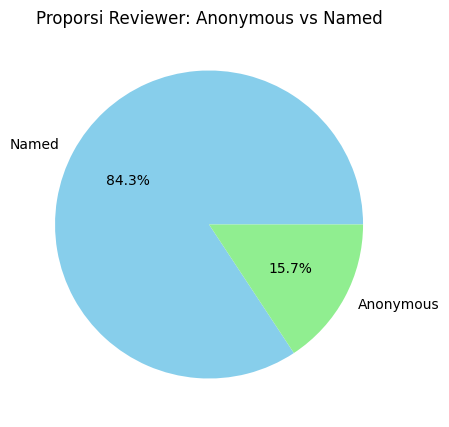

In [6]:
import matplotlib.pyplot as plt

# Pie chart distribusi reviewer
df["Reviewer_Type"].value_counts().plot(
    kind="pie", autopct='%1.1f%%', 
    colors=["skyblue","lightgreen"], 
    figsize=(5,5), ylabel=""
)
plt.title("Proporsi Reviewer: Anonymous vs Named")
plt.show()


C:\Users\72531\AppData\Local\Temp\ipykernel_288\586900269.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rating.index, y=avg_rating.values, palette="Set2")


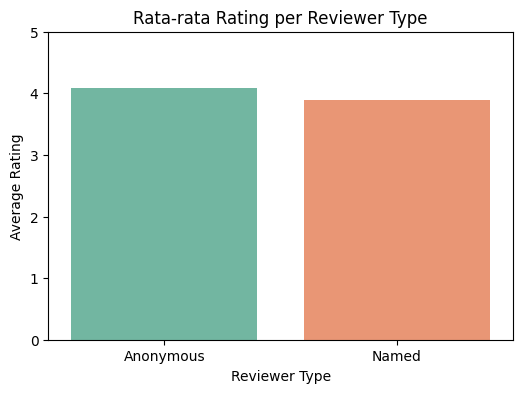

In [7]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(x=avg_rating.index, y=avg_rating.values, palette="Set2")
plt.title("Rata-rata Rating per Reviewer Type")
plt.ylabel("Average Rating")
plt.xlabel("Reviewer Type")
plt.ylim(0,5)
plt.show()


In [9]:
import pandas as pd

# Load data
df = pd.read_csv('../data/datasets/redmi6.csv', encoding='windows-1252')

# Ambil rating angka
df["Rating_value"] = df["Rating"].str.extract(r"(\d\.\d)").astype(float)

# Identifikasi Anonymous vs Named
df["Reviewer_Type"] = df["Customer name"].apply(
    lambda x: "Anonymous" if "Amazon Customer" in str(x) else "Named"
)

# Buat kategori rating (Negatif / Positif)
def label_rating(val):
    if val in [1.0, 2.0]:
        return "Negative"
    elif val in [4.0, 5.0]:
        return "Positive"
    else:
        return "Neutral"

df["Sentiment_Group"] = df["Rating_value"].apply(label_rating)

# Hitung distribusi persentase
sentiment_dist = pd.crosstab(df["Reviewer_Type"], df["Sentiment_Group"], normalize="index") * 100
print("Distribusi Sentimen (%):\n", sentiment_dist.round(2))


Distribusi Sentimen (%):
 Sentiment_Group  Negative  Neutral  Positive
Reviewer_Type                               
Anonymous            9.09    13.64     77.27
Named               20.34     8.90     70.76


In [10]:
import pandas as pd
from scipy.stats import chi2_contingency

# Load data
df = pd.read_csv('../data/datasets/redmi6.csv', encoding='windows-1252')

# Ambil rating angka
df["Rating_value"] = df["Rating"].str.extract(r"(\d\.\d)").astype(float)

# Identifikasi Anonymous vs Named
df["Reviewer_Type"] = df["Customer name"].apply(lambda x: "Anonymous" if "Amazon Customer" in str(x) else "Named")

# ------------------------------
# Opsi 1: Negatif = (1,2), Positif = (4,5)
# ------------------------------
def categorize_rating_opt1(r):
    if r in [1.0, 2.0]:
        return "Negative"
    elif r in [4.0, 5.0]:
        return "Positive"
    else:
        return "Neutral"

df["Sentiment_opt1"] = df["Rating_value"].apply(categorize_rating_opt1)

# Hitung distribusi untuk Anonymous vs Named
table_opt1 = pd.crosstab(df["Reviewer_Type"], df["Sentiment_opt1"])
chi2_opt1, p_opt1, dof_opt1, exp_opt1 = chi2_contingency(table_opt1)

print("=== Opsi 1 (1,2 vs 4,5) ===")
print(table_opt1)
print(f"Chi-square = {chi2_opt1:.3f}, p-value = {p_opt1:.3f}\n")

# ------------------------------
# Opsi 2: Negatif = (1,2,3), Positif = (4,5)
# ------------------------------
def categorize_rating_opt2(r):
    if r in [1.0, 2.0, 3.0]:
        return "Negative"
    elif r in [4.0, 5.0]:
        return "Positive"
    else:
        return "Neutral"

df["Sentiment_opt2"] = df["Rating_value"].apply(categorize_rating_opt2)

# Hitung distribusi untuk Anonymous vs Named
table_opt2 = pd.crosstab(df["Reviewer_Type"], df["Sentiment_opt2"])
chi2_opt2, p_opt2, dof_opt2, exp_opt2 = chi2_contingency(table_opt2)

print("=== Opsi 2 (1,2,3 vs 4,5) ===")
print(table_opt2)
print(f"Chi-square = {chi2_opt2:.3f}, p-value = {p_opt2:.3f}")


=== Opsi 1 (1,2 vs 4,5) ===
Sentiment_opt1  Negative  Neutral  Positive
Reviewer_Type                              
Anonymous              4        6        34
Named                 48       21       167
Chi-square = 3.609, p-value = 0.165

=== Opsi 2 (1,2,3 vs 4,5) ===
Sentiment_opt2  Negative  Positive
Reviewer_Type                     
Anonymous             10        34
Named                 69       167
Chi-square = 0.488, p-value = 0.485


### Siapkan data

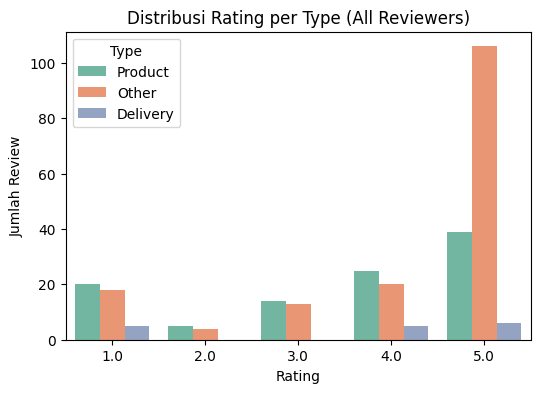

Rata-rata rating per Type (All Reviewers):
 Type
Delivery    3.437500
Other       4.192547
Product     3.563107
Name: Rating_value, dtype: float64

Distribusi rating (persentase) per Type:
 Type          Delivery      Other    Product
Rating_value                                
1.0              31.25  11.180124  19.417476
2.0               0.00   2.484472   4.854369
3.0               0.00   8.074534  13.592233
4.0              31.25  12.422360  24.271845
5.0              37.50  65.838509  37.864078


In [20]:
# === Import Library ===
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Load Data ===
df = pd.read_csv('../data/datasets/redmi6.csv', encoding='windows-1252')

# Ambil rating angka
df["Rating_value"] = df["Rating"].str.extract(r"(\d\.\d)").astype(float)

# Identifikasi Anonymous vs Named
df["Reviewer_Type"] = df["Customer name"].apply(lambda x: "Anonymous" if "Amazon Customer" in str(x) else "Named")

# Buat kolom tipe komentar: 'Delivery' atau 'Product'
delivery_keywords = ["delivery", "ship", "late", "courier", "replace", "service"]
product_keywords = ["battery", "display", "camera", "performance", "screen", "quality"]

def assign_type(comment):
    comment = str(comment).lower()
    if any(k in comment for k in delivery_keywords):
        return "Delivery"
    elif any(k in comment for k in product_keywords):
        return "Product"
    else:
        return "Other"

df["Type"] = df["Comments"].apply(assign_type)

# === Distribusi Rating per Type ===
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Rating_value", hue="Type",
              order=sorted(df["Rating_value"].dropna().unique()),
              palette="Set2")
plt.title("Distribusi Rating per Type (All Reviewers)")
plt.xlabel("Rating")
plt.ylabel("Jumlah Review")
plt.legend(title="Type")
plt.show()

# === Rata-rata Rating per Type ===
avg_rating_type = df.groupby("Type")["Rating_value"].mean()
print("Rata-rata rating per Type (All Reviewers):\n", avg_rating_type)

# === Distribusi Persentase Rating per Type ===
rating_count = pd.crosstab(df["Rating_value"], df["Type"])
rating_percent = rating_count.apply(lambda x: 100 * x / x.sum())
print("\nDistribusi rating (persentase) per Type:\n", rating_percent)


In [63]:
import pandas as pd

# Load data
df = pd.read_csv('../data/datasets/redmi6.csv', encoding='windows-1252')

# Ambil rating angka
df["Rating_value"] = df["Rating"].str.extract(r"(\d\.\d)").astype(float)

# Gabungkan reviewer (Anonymous + Named) → tidak dibedakan lagi
df["Reviewer_Type"] = df["Customer name"].apply(lambda x: "Anonymous" if "Amazon Customer" in str(x) else "Named")

print("Jumlah data:", len(df))
df[["Comments", "Rating_value"]].head(10)


Jumlah data: 280


,Comments,Rating_value
0,Another Midrange killer Smartphone by Xiaomi\r\n\r\nMajor Highlights:\r\n• T...,4.0
1,All ok but vry small size mobile,3.0
2,Quite good,3.0
3,Redmi has always have been the the king of budget segment.And yet another th...,5.0
4,worst product from MI. I am a hardcore fan of MI. But this one really disapp...,2.0
5,Over prised by at least around Rs.1000/- Low light photos are bad. Only one ...,3.0
6,Pros:\r\nnotch display\r\nDual camera\r\nFace unlock\r\n4000 mah battery\r\n...,4.0
7,Front camera is poor rest things are good,4.0
8,Wooo,5.0
9,Realme is sub brand of oppo\r\nHe give money to all techi youtubers includin...,5.0


In [16]:
%pip install bardapi

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 18.4 MB/s  0:00:00

   ------ ---------------------------------  2/12 [pycryptodomex]
   ------ ---------------------------------  2/12 [pycryptodomex]
   ------ ---------------------------------  2/12 [pycryptodomex]
   ------ ---------------------------------  2/12 [pycryptodomex]
   ------ ---------------------------------  2/12 [pycryptodomex]
   ------ ---------------------------------  2/12 [pycryptodomex]
   ------ ---------------------------------  2/12 [pycryptodomex]
   ------ ---------------------------------  2/12 [pycryptodomex]
   ------ ---------------------------------  2/12 [pycryptodomex]
   ------ ---------------------------------  2/12 [pycryptodomex]
   ------ ---------------------------------  2/12 [pycryptodomex]
   ------ ---------------------------------  2/12 [pycryptodomex]
   ------ ---------------------------------  2/12 [pycryptodomex

In [67]:
from bardapi import Bard
import pandas as pd

# inisialisasi Bard dengan cookie atau token dari sesi web Anda
token = "g.a0001wiCpTE3plFhhg3fy_Uy3PMVoOi9MgrMTqqRDlyD2CGGJEQ5HFhokKBUPad9h50TMZGgpQACgYKAQwSARUSFQHGX2MiDDonNRF8J3MAC73zsvlVZhoVAUF8yKqhH_UfPBokP3iYhkFVOjPj0076"
bard = Bard(token=token)

def classify_with_bard(comment):
    prompt = f"""
    Classify this review comment into one theme: 
    Performance, Usability, Value, Service, Mixed, Other.

    Review: "{comment}"
    """
    res = bard.get_answer(prompt)
    # tergantung format output dari bardapi; kita ambil hasil teks saja
    return res['content']

# Contoh:
df = pd.read_csv('../data/datasets/redmi6.csv', encoding='windows-1252')
df["Theme_Bard"] = df["Comments"].astype(str).apply(classify_with_bard)

df[["Comments", "Theme_Bard"]].head(10)


,Comments,Theme_Bard
0,Another Midrange killer Smartphone by Xiaomi\r\n\r\nMajor Highlights:\r\n• T...,The review comment should be classified as **Mixed**.\n\n---\n\n### Rational...
1,All ok but vry small size mobile,The review comment should be classified as **Usability**.\n\n---\n\n### Rati...
2,Quite good,The review comment should be classified as **Other**.\n\n---\n\n### Rational...
3,Redmi has always have been the the king of budget segment.And yet another th...,The review comment should be classified as **Value**.\n\n---\n\n### Rational...
4,worst product from MI. I am a hardcore fan of MI. But this one really disapp...,The review comment should be classified as **Other**.\n\n---\n\n### Rational...
5,Over prised by at least around Rs.1000/- Low light photos are bad. Only one ...,The review comment should be classified as **Mixed**.\n\n---\n\n### Rational...
6,Pros:\r\nnotch display\r\nDual camera\r\nFace unlock\r\n4000 mah battery\r\n...,The review comment should be classified as **Value**.\n\n---\n\n### Rational...
7,Front camera is poor rest things are good,The review comment should be classified as **Mixed**.\n\n---\n\n### Rational...
8,Wooo,The review comment should be classified as **Other**.\n\n---\n\n### Rational...
9,Realme is sub brand of oppo\r\nHe give money to all techi youtubers includin...,The review comment should be classified as **Value**.\n\n---\n\n### Rational...


In [145]:
# Simpan seluruh dataframe (termasuk kolom baru Theme_Bard) ke file CSV baru
df.to_csv('../data/datasets/redmi6_with_theme.csv', index=False, encoding='utf-8')


In [68]:
import pandas as pd

# kembalikan ke default (50 karakter)
pd.set_option('display.max_colwidth', 50)


In [123]:
import re

def extract_theme_correct(text):
    try:
        # Cari tema yang valid dalam teks
        match = re.search(r"(Performance|Usability|Value|Service|Mixed|Other)", text, re.IGNORECASE)
        if match:
            return match.group(1).capitalize()
        else:
            return "Other"
    except:
        return "Other"

df["Theme_Label"] = df["Theme_Bard"].astype(str).apply(extract_theme_correct)
df[["Comments", "Theme_Bard", "Theme_Label"]].head(10)


,Comments,Theme_Bard,Theme_Label
0,Another Midrange killer Smartphone by Xiaomi\r...,The review comment should be classified as **M...,Mixed
1,All ok but vry small size mobile,The review comment should be classified as **U...,Usability
2,Quite good,The review comment should be classified as **O...,Other
3,Redmi has always have been the the king of bud...,The review comment should be classified as **V...,Value
4,worst product from MI. I am a hardcore fan of ...,The review comment should be classified as **O...,Other
5,Over prised by at least around Rs.1000/- Low l...,The review comment should be classified as **M...,Mixed
6,Pros:\r\nnotch display\r\nDual camera\r\nFace ...,The review comment should be classified as **V...,Value
7,Front camera is poor rest things are good,The review comment should be classified as **M...,Mixed
8,Wooo,The review comment should be classified as **O...,Other
9,Realme is sub brand of oppo\r\nHe give money t...,The review comment should be classified as **V...,Value


In [124]:
df["Theme_Label"].value_counts()


Theme_Label
Other          113
Mixed           68
Performance     39
Value           30
Usability       21
Service          9
Name: count, dtype: int64

In [42]:
import pandas as pd

# kembalikan ke default (50 karakter)
pd.set_option('display.max_colwidth', 80)


In [125]:
mixed_comments = df[df["Theme_Label"] == "Value"]

# Lihat beberapa contoh
mixed_comments[["Comments", "Theme_Bard"]].head(10)


,Comments,Theme_Bard
3,Redmi has always have been the the king of bud...,The review comment should be classified as **V...
6,Pros:\r\nnotch display\r\nDual camera\r\nFace ...,The review comment should be classified as **V...
9,Realme is sub brand of oppo\r\nHe give money t...,The review comment should be classified as **V...
13,Redmi has always have been the the king of bud...,The review comment should be classified as **V...
16,Pros:\r\nnotch display\r\nDual camera\r\nFace ...,The review comment should be classified as **V...
19,Realme is sub brand of oppo\r\nHe give money t...,The review comment should be classified as **V...
20,awesome product at this range,The review comment should be classified as **V...
29,Good phone at such a valuable price. Notch dis...,The review comment should be classified as **V...
35,very good phone of this budget......red colour...,The review comment should be classified as **V...
38,"Good phone in budget. Good camera,battery and ...",The review comment should be classified as **V...


In [135]:
mixed_comments = df[df["Theme_Label"] == "Other"]

# Lihat beberapa contoh
mixed_comments[["Comments", "Theme_Bard"]].head(40)


,Comments,Theme_Bard
2,Quite good,The review comment should be classified as **O...
4,worst product from MI. I am a hardcore fan of ...,The review comment should be classified as **O...
8,Wooo,The review comment should be classified as **O...
12,Quite good,The review comment should be classified as **O...
14,worst product from MI. I am a hardcore fan of ...,The review comment should be classified as **O...
18,Wooo,The review comment should be classified as **O...
30,Good phone,The review comment should be classified as **O...
31,"Great product, fully met my expectations....",The review comment should be classified as **O...
32,Good,The review comment should be classified as **O...
33,Do not buy.,The review comment should be classified as **O...


In [129]:
mixed_comments = df[df["Theme_Label"] == "Usability"]

# Lihat beberapa contoh
mixed_comments[["Comments", "Theme_Bard"]].head(40)


,Comments,Theme_Bard
1,All ok but vry small size mobile,The review comment should be classified as **U...
11,All ok but vry small size mobile,The review comment should be classified as **U...
22,Like every things but fullscreen video playing...,The review comment should be classified as **U...
26,The product is great with quite good features....,The review comment should be classified as **U...
34,No dual 4g if you think new mobile you buy rea...,The review comment should be classified as **U...
51,Like everything besides display.,The review comment should be classified as **U...
55,Worst phone from MI and Amazon\r\nTouch was no...,The review comment should be classified as **U...
82,Display is best.,The review comment should be classified as **U...
107,Best notch light weight phon.,The review comment should be classified as **U...
109,The Product is Bulky would have bring the weig...,The review comment should be classified as **U...


In [130]:
mixed_comments = df[df["Theme_Label"] == "Performance"]

# Lihat beberapa contoh
mixed_comments[["Comments", "Theme_Bard"]].head(40)


,Comments,Theme_Bard
23,Please don't buy these product.. I have 3-mobi...,The review comment should be classified as **P...
24,"Thanks alot Amazon,ecom & seller.perfect produ...",The review comment should be classified as **P...
25,No company can provide u these features\r\nPro...,The review comment should be classified as **P...
28,Superb job by Xiaomi\r\nHandy phone. Not huge ...,The review comment should be classified as **P...
37,Bad camera quality and heating problem,The review comment should be classified as **P...
47,Bad camera quality and heating problem,The review comment should be classified as **P...
58,This product is very nice and battery life and...,The review comment should be classified as **P...
66,Redmi is always good for me and Redmi 6 pro pe...,The review comment should be classified as **P...
77,Phone is good Quality Dual Camera is Very Best...,The review comment should be classified as **P...
87,this mobile awesome.... i loved it best batter...,The review comment should be classified as **P...


C:\Users\72531\AppData\Local\Temp\ipykernel_288\1346291872.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")


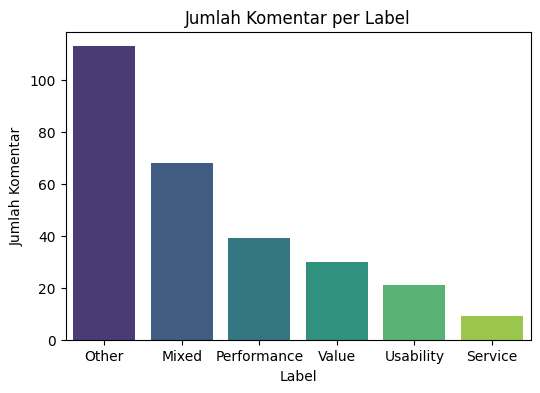

In [127]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# misal df sudah ada dan ada kolom Theme_Label
label_counts = df['Theme_Label'].value_counts()

# visualisasi bar chart
plt.figure(figsize=(6,4))
sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")
plt.title("Jumlah Komentar per Label")
plt.ylabel("Jumlah Komentar")
plt.xlabel("Label")
plt.show()


In [173]:
df

,Review Title,Customer name,Rating,Date,Category,Comments,Useful,Theme_Bard,Theme_Label,Performance_Subcategory
0,Another Midrange killer Smartphone by Xiaomi,Rishikumar Thakur,4,on 1 October 2018,Display,Another Midrange killer Smartphone by Xiaomi\r...,,The review comment should be classified as **M...,Mixed,
1,vry small size mobile,Raza ji,3,on 15 September 2018,Others,All ok but vry small size mobile,7 people found this helpful,The review comment should be classified as **U...,Usability,
2,Full display not working in all application.,Vaibhav Patel,3,on 18 September 2018,Others,Quite good,7 people found this helpful,The review comment should be classified as **O...,Other,
3,Value for Money,Amazon Customer,5,on 28 September 2018,Display,Redmi has always have been the the king of bud...,2 people found this helpful,The review comment should be classified as **V...,Value,
4,Not worth for the money,Sudhakaran Wadakkancheri,2,on 18 September 2018,Others,worst product from MI. I am a hardcore fan of ...,6 people found this helpful,The review comment should be classified as **O...,Other,
...,...,...,...,...,...,...,...,...,...,...
275,"Cemera quality,face unlock most important in t...",Rahul,5,on 19 September 2018,Others,"I like This Phone, Awesome look and design.\r\...",NaN,The review comment should be classified as **U...,Usability,
276,Mi is best phone,Sunil Soni,4,on 18 September 2018,Others,Product is avasome but invoice is note include...,NaN,The review comment should be classified as **M...,Mixed,
277,Its a OK Phone,D.C.Padhi,3,on 15 September 2018,Battery,"Redmi Note4, Note5, now 6pro..It seems the old...",NaN,The review comment should be classified as **M...,Mixed,
278,Redmi,Mahesh,5,on 21 September 2018,Others,I love mi,NaN,The review comment should be classified as **O...,Other,


In [133]:
rating_count_per_label = df.groupby('Theme_Label')['Rating'].value_counts().unstack(fill_value=0)

# Pastikan kolom hanya 1–5
rating_count_per_label = rating_count_per_label[[1,2,3,4,5]]

print(rating_count_per_label)


Rating        1  2   3   4   5
Theme_Label                   
Mixed        20  2  11  17  18
Other         8  2   8  15  80
Performance  11  3   3   3  19
Service       2  0   0   4   3
Usability     1  1   4   6   9
Value         1  1   1   5  22


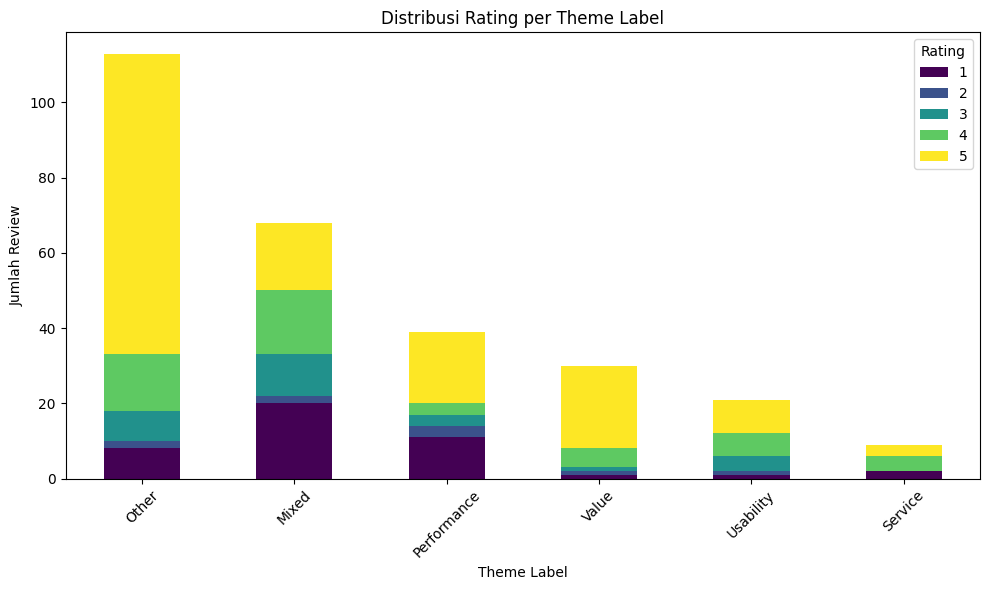

In [243]:
import matplotlib.pyplot as plt

# Hitung total review per label
rating_count_per_label['Total'] = rating_count_per_label.sum(axis=1)

# Urutkan descending berdasarkan total
rating_count_sorted = rating_count_per_label.sort_values(by='Total', ascending=False)

# Hapus kolom Total sebelum plot
rating_count_sorted = rating_count_sorted.drop(columns='Total')

# Plot stacked bar chart
rating_count_sorted.plot(kind='bar', stacked=True, figsize=(10,6), colormap='viridis')

plt.title('Distribusi Rating per Theme Label')
plt.xlabel('Theme Label')
plt.ylabel('Jumlah Review')
plt.legend(title='Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


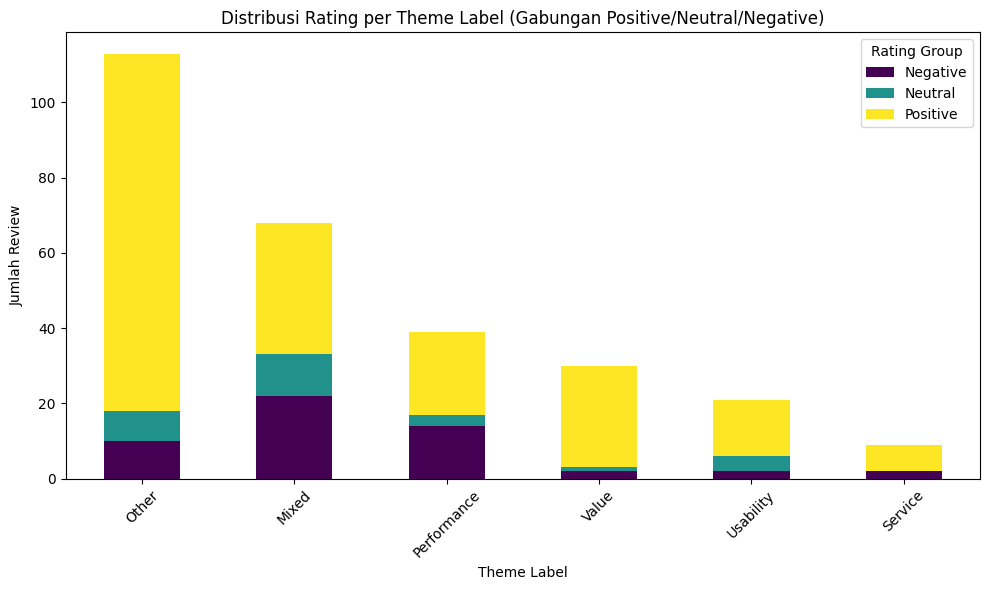

In [247]:
import matplotlib.pyplot as plt
import pandas as pd

# Contoh: rating_count_per_label sudah berupa pivot table seperti sebelumnya
# Kolom awal: 1,2,3,4,5

# Buat kolom baru untuk gabungan
rating_count_per_label_grouped = pd.DataFrame()
rating_count_per_label_grouped['Negative'] = rating_count_per_label[[1,2]].sum(axis=1)
rating_count_per_label_grouped['Neutral'] = rating_count_per_label[[3]]
rating_count_per_label_grouped['Positive'] = rating_count_per_label[[4,5]].sum(axis=1)

# Hitung total per label untuk sorting
rating_count_per_label_grouped['Total'] = rating_count_per_label_grouped.sum(axis=1)

# Urutkan descending berdasarkan total
rating_count_sorted = rating_count_per_label_grouped.sort_values(by='Total', ascending=False)

# Hapus kolom Total sebelum plot
rating_count_sorted = rating_count_sorted.drop(columns='Total')

# Plot stacked bar chart
rating_count_sorted.plot(kind='bar', stacked=True, figsize=(10,6), colormap='viridis')

plt.title('Distribusi Rating per Theme Label (Gabungan Positive/Neutral/Negative)')
plt.xlabel('Theme Label')
plt.ylabel('Jumlah Review')
plt.legend(title='Rating Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [248]:
import pandas as pd
import matplotlib.pyplot as plt
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

# Klasifikasi komentar
def classify_comment(comment):
    if pd.isna(comment):
        return 'Neutral'
    score = sia.polarity_scores(comment)['compound']
    if score <= -0.6:
        return 'Very Negative'
    elif score <= -0.2:
        return 'Negative'
    elif score < 0.2:
        return 'Neutral'
    elif score < 0.6:
        return 'Positive'
    else:
        return 'Very Positive'

df['Comment_Category'] = df['Comments'].apply(classify_comment)

# Gabungkan rating menjadi 3 kelompok
def rating_group(rating):
    if rating in [1,2]:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['Rating_Group'] = df['Rating_num'].apply(rating_group)

# Pivot table untuk rating
pivot_rating_group = df.pivot_table(
    index='Theme Label',
    columns='Rating_Group',
    values='Comments',
    aggfunc='count',
    fill_value=0
)

# Pivot table untuk komentar
pivot_comment_category = df.pivot_table(
    index='Theme Label',
    columns='Comment_Category',
    values='Comments',
    aggfunc='count',
    fill_value=0
)

# Urutkan berdasarkan total rating (optional)
pivot_rating_group = pivot_rating_group.loc[pivot_rating_group.sum(axis=1).sort_values(ascending=False).index]
pivot_comment_category = pivot_comment_category.loc[pivot_rating_group.index]  # samakan urutan

# Plot side-by-side stacked bar
fig, ax = plt.subplots(1, 2, figsize=(16,6))

pivot_rating_group.plot(kind='bar', stacked=True, ax=ax[0], colormap='coolwarm')
ax[0].set_title('Rating Group per Theme Label')
ax[0].set_ylabel('Jumlah Review')
ax[0].set_xlabel('Theme Label')
ax[0].legend(title='Rating Group', bbox_to_anchor=(1.05,1), loc='upper left')

pivot_comment_category.plot(kind='bar', stacked=True, ax=ax[1], colormap='viridis')
ax[1].set_title('Comment Sentiment per Theme Label')
ax[1].set_ylabel('Jumlah Review')
ax[1].set_xlabel('Theme Label')
ax[1].legend(title='Comment Category', bbox_to_anchor=(1.05,1), loc='upper left')

plt.tight_layout()
plt.show()


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\72531\AppData\Roaming\nltk_data...


KeyError: 'Rating_num'

In [136]:
# Rating rendah = 1 & 2
rating_low = rating_count_per_label[[1,2,3]].sum(axis=1)

# Rating tinggi = 4 & 5
rating_high = rating_count_per_label[[4,5]].sum(axis=1)


In [137]:
import pandas as pd

# Hitung rating rendah dan tinggi
rating_low = rating_count_per_label[[1,2,3]].sum(axis=1)
rating_high = rating_count_per_label[[4,5]].sum(axis=1)

# Gabungkan menjadi dataframe baru
highlight_df = pd.DataFrame({
    'Rating Rendah (1-3)': rating_low,
    'Rating Tinggi (4-5)': rating_high
})

# Urutkan berdasarkan total review
highlight_df['Total'] = highlight_df.sum(axis=1)
highlight_df = highlight_df.sort_values(by='Total', ascending=False).drop(columns='Total')

print(highlight_df)


             Rating Rendah (1-3)  Rating Tinggi (4-5)
Theme_Label                                          
Other                         18                   95
Mixed                         33                   35
Performance                   17                   22
Value                          3                   27
Usability                      6                   15
Service                        2                    7


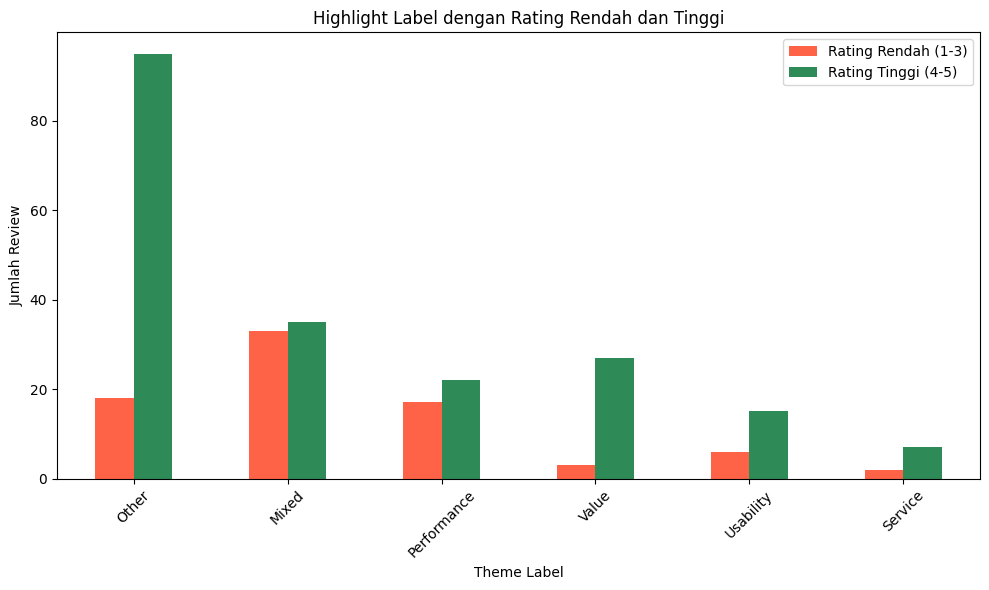

In [138]:
import matplotlib.pyplot as plt

highlight_df.plot(kind='bar', figsize=(10,6), color=['tomato', 'seagreen'])

plt.title('Highlight Label dengan Rating Rendah dan Tinggi')
plt.xlabel('Theme Label')
plt.ylabel('Jumlah Review')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [118]:
import pandas as pd

# Misal df sudah ter-load
# Ambil angka sebelum " out of"
df['Rating'] = df['Rating'].str.extract(r'(\d+\.?\d*)').astype(float)

# Jika ingin integer
df['Rating'] = df['Rating'].astype(int)

print(df[['Rating']].head())


   Rating
0       4
1       3
2       3
3       5
4       2


In [100]:
rating_count_per_label['Total'] = rating_count_per_label.sum(axis=1)
rating_count_sorted = rating_count_per_label.sort_values(by='Total', ascending=False).drop(columns='Total')


In [101]:
# Rating rendah = 1 & 2
rating_low = rating_count_per_label[[1,2]].sum(axis=1)

# Rating tinggi = 4 & 5
rating_high = rating_count_per_label[[4,5]].sum(axis=1)


In [245]:
import pandas as pd

# Hitung rating rendah dan tinggi
rating_low = rating_count_per_label[[1,2]].sum(axis=1)
rating_high = rating_count_per_label[[4,5]].sum(axis=1)

# Gabungkan menjadi dataframe baru
highlight_df = pd.DataFrame({
    'Rating Rendah (1-2)': rating_low,
    'Rating Tinggi (4-5)': rating_high
})

# Urutkan berdasarkan total review
highlight_df['Total'] = highlight_df.sum(axis=1)
highlight_df = highlight_df.sort_values(by='Total', ascending=False).drop(columns='Total')

print(highlight_df)


             Rating Rendah (1-2)  Rating Tinggi (4-5)
Theme_Label                                          
Other                         10                   95
Mixed                         22                   35
Performance                   14                   22
Value                          2                   27
Usability                      2                   15
Service                        2                    7


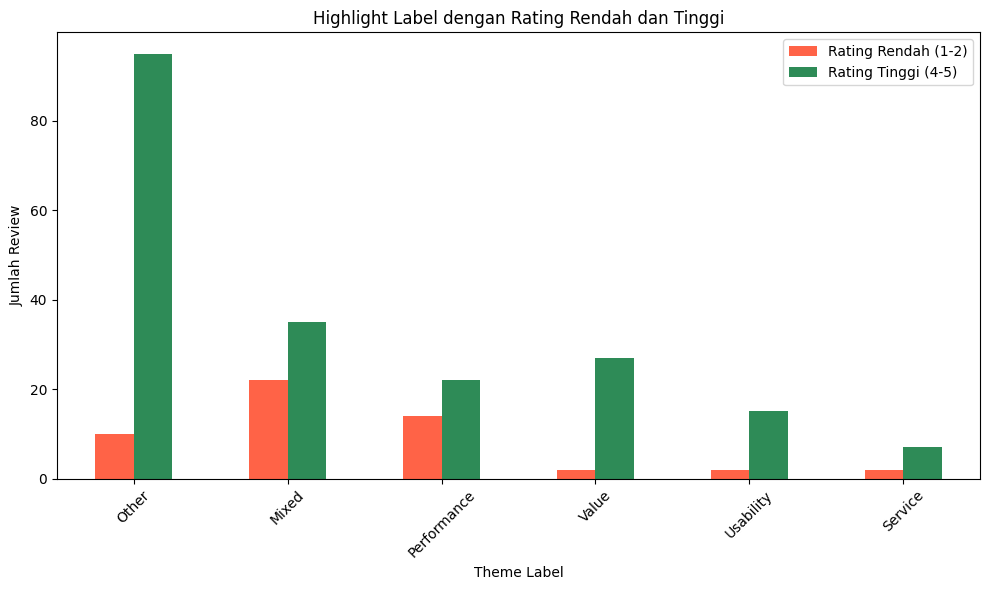

In [246]:
import matplotlib.pyplot as plt

highlight_df.plot(kind='bar', figsize=(10,6), color=['tomato', 'seagreen'])

plt.title('Highlight Label dengan Rating Rendah dan Tinggi')
plt.xlabel('Theme Label')
plt.ylabel('Jumlah Review')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [141]:
import pandas as pd

# Filter komentar dengan Theme_Label = 'Other' dan Rating = 5
other_rating5_df = df[(df['Theme_Label'] == 'Other') & (df['Rating'] == 4)]

# Tampilkan hasil
print(other_rating5_df[['Comments', 'Rating']])


                 Comments  Rating
32                   Good       4
42                   Good       4
80             Good phone       4
111         Good mm??????       4
146  Phone system is nice       4
147  Mobile is very nice.       4
154                  Nice       4
163                    ??       4
175        Superb product       4
183                  Good       4
185                  Good       4
190           Nice mobile       4
193            Best phone       4
195              Good one       4
202                  Nice       4


In [112]:
import pandas as pd

# Filter hanya comment dengan Theme_Label = 'performance'
performance_df = df[df['Theme_Label'] == 'Performance']

# Filter rating tinggi (>=4)
strong_points = performance_df[performance_df['Rating'] >= 4]

# Filter rating rendah (<=2)
problem_areas = performance_df[performance_df['Rating'] <= 2]

# Tampilkan hasil
print("=== Strong Points (Rating >= 4) ===")
print(strong_points[['Comments', 'Rating']])

print("\n=== Problem Areas (Rating <= 2) ===")
print(problem_areas[['Comments', 'Rating']])


=== Strong Points (Rating >= 4) ===
                                              Comments  Rating
24   Thanks alot Amazon,ecom & seller.perfect produ...       5
25   No company can provide u these features\r\nPro...       5
28   Superb job by Xiaomi\r\nHandy phone. Not huge ...       5
30                                          Good phone       5
31        Great product, fully met my expectations....       5
..                                                 ...     ...
251                                               Good       5
254                                    Bettary so good       5
259                             Dislike snapdragon 425       4
260  the camera is good, phone is fast overall work...       5
278                                          I love mi       5

[74 rows x 2 columns]

=== Problem Areas (Rating <= 2) ===
                                              Comments  Rating
4    worst product from MI. I am a hardcore fan of ...       2
23   Please don't buy 

In [152]:
df

,Review Title,Customer name,Rating,Date,Category,Comments,Useful,Theme_Bard,Theme_Label,Performance_Subcategory
0,Another Midrange killer Smartphone by Xiaomi,Rishikumar Thakur,4,on 1 October 2018,Display,Another Midrange killer Smartphone by Xiaomi\r...,,The review comment should be classified as **M...,Mixed,
1,vry small size mobile,Raza ji,3,on 15 September 2018,Others,All ok but vry small size mobile,7 people found this helpful,The review comment should be classified as **U...,Usability,
2,Full display not working in all application.,Vaibhav Patel,3,on 18 September 2018,Others,Quite good,7 people found this helpful,The review comment should be classified as **O...,Other,
3,Value for Money,Amazon Customer,5,on 28 September 2018,Display,Redmi has always have been the the king of bud...,2 people found this helpful,The review comment should be classified as **V...,Value,
4,Not worth for the money,Sudhakaran Wadakkancheri,2,on 18 September 2018,Others,worst product from MI. I am a hardcore fan of ...,6 people found this helpful,The review comment should be classified as **O...,Other,
...,...,...,...,...,...,...,...,...,...,...
275,"Cemera quality,face unlock most important in t...",Rahul,5,on 19 September 2018,Others,"I like This Phone, Awesome look and design.\r\...",NaN,The review comment should be classified as **U...,Usability,
276,Mi is best phone,Sunil Soni,4,on 18 September 2018,Others,Product is avasome but invoice is note include...,NaN,The review comment should be classified as **M...,Mixed,
277,Its a OK Phone,D.C.Padhi,3,on 15 September 2018,Battery,"Redmi Note4, Note5, now 6pro..It seems the old...",NaN,The review comment should be classified as **M...,Mixed,
278,Redmi,Mahesh,5,on 21 September 2018,Others,I love mi,NaN,The review comment should be classified as **O...,Other,


In [153]:
from bardapi import Bard
import pandas as pd

# inisialisasi Bard
token = "g.a0001wiCpTE3plFhhg3fy_Uy3PMVoOi9MgrMTqqRDlyD2CGGJEQ5HFhokKBUPad9h50TMZGgpQACgYKAQwSARUSFQHGX2MiDDonNRF8J3MAC73zsvlVZhoVAUF8yKqhH_UfPBokP3iYhkFVOjPj0076"
bard = Bard(token=token)

def classify_performance(comment):
    prompt = f"""
    This review comment is classified as Performance. 
    Further classify it into exactly one sub-category:
    Camera, Battery, Processor, Sound/Speaker, or General.

    Comment: "{comment}"

    Only respond with one of: Camera, Battery, Processor, Sound/Speaker, General
    """
    res = bard.get_answer(prompt)
    # Ambil teks jawaban Bard
    result = res['content'].strip()
    
    # Validasi jawaban, jika tidak sesuai kategori, default ke General
    if result not in ['Camera', 'Battery', 'Processor', 'Sound/Speaker', 'General']:
        result = 'General'
    
    return result

# Misal df sudah ada dan kolom Theme_Bard sebelumnya sudah diisi
# Kita hanya proses komentar yang Theme_Bard = 'Performance'
performance_indices = df[df['Theme_Label'] == 'Performance'].index

# Tambahkan kolom baru untuk subkategori Performance
df['Performance_Subcategory'] = ''

for i in performance_indices:
    comment = df.loc[i, 'Comments']
    df.loc[i, 'Performance_Subcategory'] = classify_performance(comment)


In [171]:
df

,Review Title,Customer name,Rating,Date,Category,Comments,Useful,Theme_Bard,Theme_Label,Performance_Subcategory
0,Another Midrange killer Smartphone by Xiaomi,Rishikumar Thakur,4,on 1 October 2018,Display,Another Midrange killer Smartphone by Xiaomi\r...,,The review comment should be classified as **M...,Mixed,
1,vry small size mobile,Raza ji,3,on 15 September 2018,Others,All ok but vry small size mobile,7 people found this helpful,The review comment should be classified as **U...,Usability,
2,Full display not working in all application.,Vaibhav Patel,3,on 18 September 2018,Others,Quite good,7 people found this helpful,The review comment should be classified as **O...,Other,
3,Value for Money,Amazon Customer,5,on 28 September 2018,Display,Redmi has always have been the the king of bud...,2 people found this helpful,The review comment should be classified as **V...,Value,
4,Not worth for the money,Sudhakaran Wadakkancheri,2,on 18 September 2018,Others,worst product from MI. I am a hardcore fan of ...,6 people found this helpful,The review comment should be classified as **O...,Other,
...,...,...,...,...,...,...,...,...,...,...
275,"Cemera quality,face unlock most important in t...",Rahul,5,on 19 September 2018,Others,"I like This Phone, Awesome look and design.\r\...",NaN,The review comment should be classified as **U...,Usability,
276,Mi is best phone,Sunil Soni,4,on 18 September 2018,Others,Product is avasome but invoice is note include...,NaN,The review comment should be classified as **M...,Mixed,
277,Its a OK Phone,D.C.Padhi,3,on 15 September 2018,Battery,"Redmi Note4, Note5, now 6pro..It seems the old...",NaN,The review comment should be classified as **M...,Mixed,
278,Redmi,Mahesh,5,on 21 September 2018,Others,I love mi,NaN,The review comment should be classified as **O...,Other,


In [174]:
# Simpan seluruh dataframe (termasuk kolom baru Theme_Bard) ke file CSV baru
df.to_csv('../data/datasets/redmi6_with_performance.csv', index=False, encoding='utf-8')


In [242]:
import pandas as pd

df = pd.read_csv('../data/datasets/redmi6_with_performance.csv', index_col=0, encoding='utf-8')
df.head(30)

Customer name  \
Review Title                                                                       
Another Midrange killer Smartphone by Xiaomi                   Rishikumar Thakur   
vry small size mobile                                                    Raza ji   
Full display not working in all application.                       Vaibhav Patel   
Value for Money                                                  Amazon Customer   
Not worth for the money                                 Sudhakaran Wadakkancheri   
Redmi 6 pro (3/32 GB) review after using for one week.            Arun Yajurvedi   
Fabulous!                                                       Irukulla bharath   
Fantastic                                                        Amazon Customer   
Good                                                             Amazon Customer   
All youtubers are paid                                                    Sharad   
Another Midrange killer Smartphone by Xiaomi                   Rishikumar Thakur   
vry small size mobile                                                    Raza ji   
Full display not working in all application.                       Vaibhav Patel   
Value for Money                                                  Amazon Customer   
Not worth for the money                                 Sudhakaran Wadakkancheri   
Redmi 6 pro (3/32 GB) review after using for one week.            Arun Yajurvedi   
Fabulous!                                                       Irukulla bharath   
Fantastic                                                        Amazon Customer   
Good                                                             Amazon Customer   
All youtubers are paid                                                    Sharad   
Awesome product                                                     Debashis Das   
08-Oct                                                       Braveheartboy_vinai   
Nice handy phone with good camera with notch                      Abhishek Gupta   
dont buy these product. these copy of the product           KHAN SONU RAFI AHMED   
Thanks alot Amazon                                                          sonu   
Pros and cons                                                    Amazon Customer   
Design can be better                                                Rahul Mhatre   
Mi 6pro review                                                   darpan n parekh   
Best phone u can get in this and within 20k budget               Amazon Customer   
Superb Phone. Good for Performance.                                       Tharun   

                                                        Rating  \
Review Title                                                     
Another Midrange killer Smartphone by Xiaomi                 4   
vry small size mobile                                        3   
Full display not working in all application.                 3   
Value for Money                                              5   
Not worth for the money                                      2   
Redmi 6 pro (3/32 GB) review after using for one week.       3   
Fabulous!                                                    4   
Fantastic                                                    4   
Good                                                         5   
All youtubers are paid                                       5   
Another Midrange killer Smartphone by Xiaomi                 4   
vry small size mobile                                        3   
Full display not working in all application.                 3   
Value for Money                                              5   
Not worth for the money                                      2   
Redmi 6 pro (3/32 GB) review after using for one week.       3   
Fabulous!                                                    4   
Fantastic                                                    4   
Good                                                      

In [178]:
# Filter komentar yang Theme_Bard = 'Performance'
performance_df = df[df['Theme_Label'] == 'Performance'] 

# Tampilkan kolom Comments dan Performance_Subcategory
print(performance_df[['Comments', 'Performance_Subcategory']].head(60))


                                              Comments Performance_Subcategory
23   Please don't buy these product.. I have 3-mobi...                 General
24   Thanks alot Amazon,ecom & seller.perfect produ...                 General
25   No company can provide u these features\r\nPro...                 General
28   Superb job by Xiaomi\r\nHandy phone. Not huge ...                 General
37              Bad camera quality and heating problem                 General
47              Bad camera quality and heating problem                 General
58   This product is very nice and battery life and...                 Battery
66   Redmi is always good for me and Redmi 6 pro pe...                 Battery
77   Phone is good Quality Dual Camera is Very Best...                  Camera
87   this mobile awesome.... i loved it best batter...                 Battery
89   Battery is good\r\nPhone is good\r\nCamera is ...                 General
93                         Sound and battery life go

In [159]:
# Filter komentar yang Theme_Label = 'Performance' **dan** Performance_Subcategory = 'Battery'
performance_df = df[(df['Theme_Label'] == 'Performance') & (df['Performance_Subcategory'] == 'Battery')]

# Tampilkan kolom Comments
print(performance_df[['Comments']].head(20))


                                              Comments
58   This product is very nice and battery life and...
66   Redmi is always good for me and Redmi 6 pro pe...
87   this mobile awesome.... i loved it best batter...
95                   Good mobile.. battery backup good
102         Display Quality and battery backup is good
104  This product is very good, battery backup is v...
180                                      Slow charging
254                                    Bettary so good
270  Please dont't bye camera is good but battery b...


In [168]:
# Filter komentar yang Theme_Label = 'Performance' **dan** Performance_Subcategory = 'Battery'
performance_df = df[(df['Theme_Label'] == 'Performance') & (df['Performance_Subcategory'] == 'Processor')]

# Tampilkan kolom Comments
print(performance_df[['Comments']].head(20))


                                              Comments
256  After using it for 10 days, I am writing it, t...
259                             Dislike snapdragon 425
273  Charging issue\r\nLagging issue\r\nhanging iss...


                                             Comments Performance_Subcategory
23  Please don't buy these product.. I have 3-mobi...                 General
24  Thanks alot Amazon,ecom & seller.perfect produ...                 General
25  No company can provide u these features\r\nPro...                 General
28  Superb job by Xiaomi\r\nHandy phone. Not huge ...                 General
37             Bad camera quality and heating problem                 General
47             Bad camera quality and heating problem                 General
58  This product is very nice and battery life and...                 Battery
66  Redmi is always good for me and Redmi 6 pro pe...                 Battery
77  Phone is good Quality Dual Camera is Very Best...                  Camera
87  this mobile awesome.... i loved it best batter...                 Battery
Jumlah komentar per subkategori Performance:
Performance_Subcategory
General          15
Battery           9
Camera            9
Sound/Speaker

C:\Users\72531\AppData\Local\Temp\ipykernel_288\768714022.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Performance_Subcategory', data=performance_df, palette='magma', order=performance_counts.index)


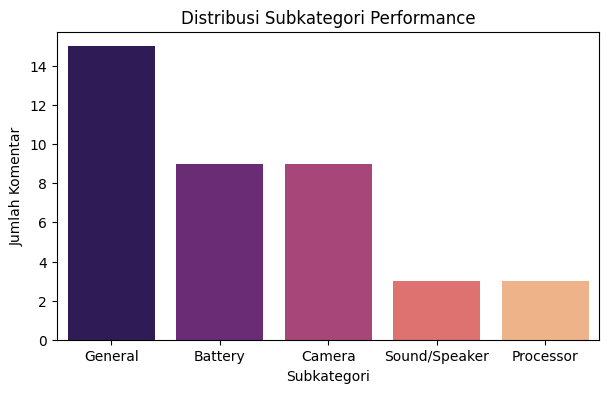

In [157]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Normalisasi Theme_Label
df['Theme_Label'] = df['Theme_Label'].str.strip().str.capitalize()

# Filter hanya komentar yang bertema Performance
performance_df = df[df['Theme_Label'] == 'Performance']

# Pastikan kolom Performance_Subcategory sudah ada, kalau belum buat default 'General'
if 'Performance_Subcategory' not in performance_df.columns:
    performance_df['Performance_Subcategory'] = 'General'

# Tampilkan beberapa data pertama
print(performance_df[['Comments', 'Performance_Subcategory']].head(10))

# Hitung jumlah komentar per subkategori
performance_counts = performance_df['Performance_Subcategory'].value_counts()
print("Jumlah komentar per subkategori Performance:")
print(performance_counts)

# Visualisasi distribusi subkategori Performance
plt.figure(figsize=(7,4))
sns.countplot(x='Performance_Subcategory', data=performance_df, palette='magma', order=performance_counts.index)
plt.title("Distribusi Subkategori Performance")
plt.xlabel("Subkategori")
plt.ylabel("Jumlah Komentar")
plt.show()


In [170]:
# Filter komentar Performance dan buat salinan agar aman
performance_df = df[df['Theme_Label'] == 'Performance'].copy()

# Pastikan Rating bertipe numerik
performance_df['Rating'] = pd.to_numeric(performance_df['Rating'], errors='coerce')

# Pivot table: index=subkategori, columns=rating, values=count
rating_count_per_subcat = performance_df.pivot_table(
    index='Performance_Subcategory',
    columns='Rating',
    values='Comments',
    aggfunc='count',
    fill_value=0
)

print("Jumlah komentar per rating untuk masing-masing subkategori Performance:")
print(rating_count_per_subcat)


Jumlah komentar per rating untuk masing-masing subkategori Performance:
Rating                   1  2  3  4  5
Performance_Subcategory               
Battery                  1  0  0  0  8
Camera                   3  1  2  2  1
General                  4  2  0  0  9
Processor                2  0  0  1  0
Sound/speaker            1  0  1  0  1


C:\Users\72531\AppData\Local\Temp\ipykernel_288\286479421.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  performance_df['Rating'] = pd.to_numeric(performance_df['Rating'], errors='coerce')


<Axes: xlabel='Performance_Subcategory'>

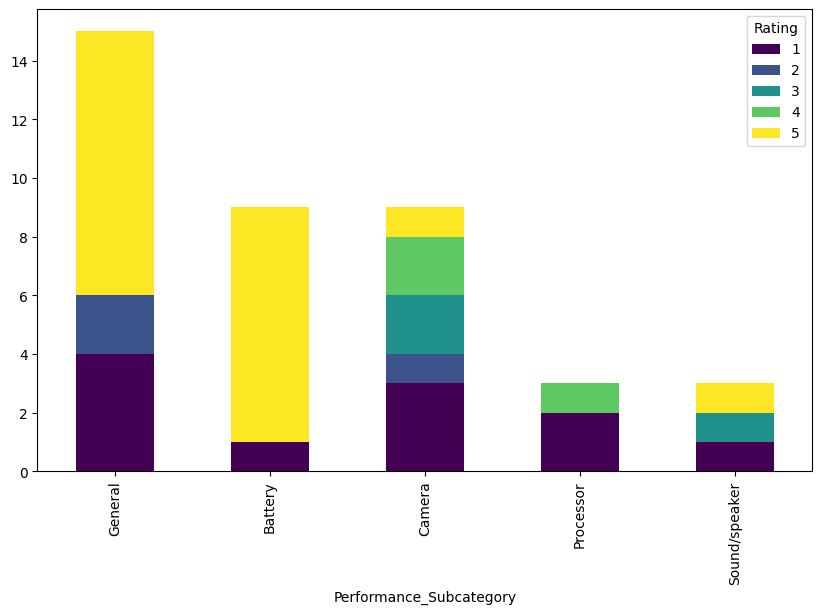

In [167]:
import pandas as pd
import matplotlib.pyplot as plt

# Pastikan Rating bertipe numerik
performance_df['Rating'] = pd.to_numeric(performance_df['Rating'], errors='coerce')

# Buat pivot table: index=subkategori, columns=Rating, values=count
rating_count_per_subcat = performance_df.pivot_table(
    index='Performance_Subcategory',
    columns='Rating',
    values='Comments',
    aggfunc='count',
    fill_value=0
)

# Hitung total review per subkategori
rating_count_per_subcat['Total'] = rating_count_per_subcat.sum(axis=1)

# Urutkan descending berdasarkan total
rating_count_sorted = rating_count_per_subcat.sort_values(by='Total', ascending=False)

# Hapus kolom Total sebelum plot
rating_count_sorted = rating_count_sorted.drop(columns='Total')

# Plot stacked bar chart
rating_count_sorted.plot(
    kind='bar', 
    stacked=True, 
    figsize=(10,6), 
    colormap='viridis'
)


In [240]:
# Filter baris dengan Category = 'Camera'
camera_rows = df[df['Category'] == 'Baterry']

# Lihat kolom Category dan Theme_Label
print(camera_rows[['Category', 'Theme_Label']])

# Cek apakah semua Category='Camera' punya Theme_Label='Performance'
all_performance = (camera_rows['Theme_Label'] == 'Performance').all()

if all_performance:
    print("Semua Category='Camera' masuk ke Theme_Label='Performance'")
else:
    print("Tidak semua Category='Camera' masuk ke Theme_Label='Performance'")


Empty DataFrame
Columns: [Category, Theme_Label]
Index: []
Semua Category='Camera' masuk ke Theme_Label='Performance'


In [186]:
# Filter baris dengan Category = 'Display'
Display_rows = df[df['Category'] == 'Display']

# Lihat kolom Category dan Theme_Label
print(Display_rows[['Category', 'Theme_Label']])

# Cek apakah semua Category='Display' punya Theme_Label='Usability'
all_Usability = (Display_rows['Theme_Label'] == 'Usability').all()

if all_Usability:
    print("Semua Category='Display' masuk ke Theme_Label='Usability'")
else:
    print("Tidak semua Category='Display' masuk ke Theme_Label='Usability'")


    Category  Theme_Label
0    Display        Mixed
3    Display        Value
5    Display        Mixed
6    Display        Value
10   Display        Mixed
13   Display        Value
15   Display        Mixed
16   Display        Value
25   Display  Performance
28   Display  Performance
29   Display        Value
51   Display    Usability
58   Display  Performance
60   Display        Value
77   Display  Performance
79   Display        Mixed
82   Display    Usability
85   Display        Mixed
102  Display  Performance
131  Display    Usability
141  Display    Usability
158  Display    Usability
219  Display        Mixed
221  Display        Mixed
224  Display        Mixed
227  Display        Mixed
230  Display        Mixed
231  Display        Mixed
235  Display        Mixed
240  Display        Mixed
241  Display        Mixed
245  Display        Mixed
250  Display        Mixed
263  Display        Mixed
268  Display        Mixed
272  Display        Mixed
Tidak semua Category='Display' masuk k

In [197]:
from bardapi import Bard
import pandas as pd

# Inisialisasi Bard
token = "g.a0001wiCpTE3plFhhg3fy_Uy3PMVoOi9MgrMTqqRDlyD2CGGJEQ5HFhokKBUPad9h50TMZGgpQACgYKAQwSARUSFQHGX2MiDDonNRF8J3MAC73zsvlVZhoVAUF8yKqhH_UfPBokP3iYhkFVOjPj0076"
bard = Bard(token=token)

def classify_sentiment(comment):
    prompt = f"""
    Classify the sentiment of this review comment into exactly one category:
    Very Negative, Negative, Neutral, Positive, Very Positive.

    Comment: "{comment}"

    Only respond with one of: Very Negative, Negative, Neutral, Positive, Very Positive
    """
    res = bard.get_answer(prompt)
    # Ambil teks jawaban Bard
    result = res['content'].strip()
    
    # Validasi jawaban, jika tidak sesuai kategori, default ke Neutral
    if result not in ['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive']:
        result = 'Neutral'
    
    return result

# Tambahkan kolom baru untuk sentiment
df['Sentiment_Bard'] = df['Comments'].astype(str).apply(classify_sentiment)

# Lihat hasil
df[['Comments', 'Sentiment_Bard']].head(10)


,Comments,Sentiment_Bard
0,Another Midrange killer Smartphone by Xiaomi\r...,Positive
1,All ok but vry small size mobile,Neutral
2,Quite good,Positive
3,Redmi has always have been the the king of bud...,Very Positive
4,worst product from MI. I am a hardcore fan of ...,Very Negative
5,Over prised by at least around Rs.1000/- Low l...,Positive
6,Pros:\r\nnotch display\r\nDual camera\r\nFace ...,Positive
7,Front camera is poor rest things are good,Neutral
8,Wooo,Neutral
9,Realme is sub brand of oppo\r\nHe give money t...,Positive


In [ ]:
# Simpan seluruh dataframe (termasuk kolom baru Theme_Bard) ke file CSV baru
df.to_csv('../data/datasets/redmi6_with_sentiment.csv', index=False, encoding='utf-8')



In [206]:
import pandas as pd

df = pd.read_csv('../data/datasets/redmi6_with_sentiment.csv', encoding='utf-8')
df

,Review Title,Customer name,Rating,Date,Category,Comments,Useful,Rating_value,Sentiment_Bard
0,Another Midrange killer Smartphone by Xiaomi,Rishikumar Thakur,4.0 out of 5 stars,on 1 October 2018,Display,Another Midrange killer Smartphone by Xiaomi\r...,,4.0,Positive
1,vry small size mobile,Raza ji,3.0 out of 5 stars,on 15 September 2018,Others,All ok but vry small size mobile,7 people found this helpful,3.0,Neutral
2,Full display not working in all application.,Vaibhav Patel,3.0 out of 5 stars,on 18 September 2018,Others,Quite good,7 people found this helpful,3.0,Positive
3,Value for Money,Amazon Customer,5.0 out of 5 stars,on 28 September 2018,Display,Redmi has always have been the the king of bud...,2 people found this helpful,5.0,Very Positive
4,Not worth for the money,Sudhakaran Wadakkancheri,2.0 out of 5 stars,on 18 September 2018,Others,worst product from MI. I am a hardcore fan of ...,6 people found this helpful,2.0,Very Negative
...,...,...,...,...,...,...,...,...,...
275,"Cemera quality,face unlock most important in t...",Rahul,5.0 out of 5 stars,on 19 September 2018,Others,"I like This Phone, Awesome look and design.\r\...",NaN,5.0,Very Positive
276,Mi is best phone,Sunil Soni,4.0 out of 5 stars,on 18 September 2018,Others,Product is avasome but invoice is note include...,NaN,4.0,Neutral
277,Its a OK Phone,D.C.Padhi,3.0 out of 5 stars,on 15 September 2018,Battery,"Redmi Note4, Note5, now 6pro..It seems the old...",NaN,3.0,Neutral
278,Redmi,Mahesh,5.0 out of 5 stars,on 21 September 2018,Others,I love mi,NaN,5.0,Very Positive


In [207]:
import pandas as pd

# Baca kedua CSV
df1 = pd.read_csv('../data/datasets/redmi6_with_sentiment.csv', encoding='utf-8')  # berisi Sentiment_Bard
df2 = pd.read_csv('../data/datasets/redmi6_with_performance.csv', encoding='utf-8')  # data utama

# Merge berdasarkan kolom Comments
df_merged = df2.merge(
    df1[['Comments', 'Sentiment_Bard']],  # hanya ambil kolom yang dibutuhkan
    on='Comments',  # merge berdasarkan komentar
    how='left'      # left join supaya df2 tetap lengkap
)

# Cek hasil
print(df_merged.head())


                                   Review Title      Customer name  Rating  \
0  Another Midrange killer Smartphone by Xiaomi  Rishikumar Thakur       4   
1                         vry small size mobile            Raza ji       3   
2                         vry small size mobile            Raza ji       3   
3  Full display not working in all application.      Vaibhav Patel       3   
4  Full display not working in all application.      Vaibhav Patel       3   

                   Date Category  \
0     on 1 October 2018  Display   
1  on 15 September 2018   Others   
2  on 15 September 2018   Others   
3  on 18 September 2018   Others   
4  on 18 September 2018   Others   

                                            Comments  \
0  Another Midrange killer Smartphone by Xiaomi\r...   
1                   All ok but vry small size mobile   
2                   All ok but vry small size mobile   
3                                         Quite good   
4                                 

In [209]:
df_merged

,Review Title,Customer name,Rating,Date,Category,Comments,Useful,Theme_Bard,Theme_Label,Performance_Subcategory,Sentiment_Bard
0,Another Midrange killer Smartphone by Xiaomi,Rishikumar Thakur,4,on 1 October 2018,Display,Another Midrange killer Smartphone by Xiaomi\r...,,The review comment should be classified as **M...,Mixed,NaN,NaN
1,vry small size mobile,Raza ji,3,on 15 September 2018,Others,All ok but vry small size mobile,7 people found this helpful,The review comment should be classified as **U...,Usability,NaN,Neutral
2,vry small size mobile,Raza ji,3,on 15 September 2018,Others,All ok but vry small size mobile,7 people found this helpful,The review comment should be classified as **U...,Usability,NaN,Neutral
3,Full display not working in all application.,Vaibhav Patel,3,on 18 September 2018,Others,Quite good,7 people found this helpful,The review comment should be classified as **O...,Other,NaN,Positive
4,Full display not working in all application.,Vaibhav Patel,3,on 18 September 2018,Others,Quite good,7 people found this helpful,The review comment should be classified as **O...,Other,NaN,Positive
...,...,...,...,...,...,...,...,...,...,...,...
727,"Cemera quality,face unlock most important in t...",Rahul,5,on 19 September 2018,Others,"I like This Phone, Awesome look and design.\r\...",NaN,The review comment should be classified as **U...,Usability,NaN,Very Positive
728,Mi is best phone,Sunil Soni,4,on 18 September 2018,Others,Product is avasome but invoice is note include...,NaN,The review comment should be classified as **M...,Mixed,NaN,Neutral
729,Its a OK Phone,D.C.Padhi,3,on 15 September 2018,Battery,"Redmi Note4, Note5, now 6pro..It seems the old...",NaN,The review comment should be classified as **M...,Mixed,NaN,Neutral
730,Redmi,Mahesh,5,on 21 September 2018,Others,I love mi,NaN,The review comment should be classified as **O...,Other,NaN,Very Positive


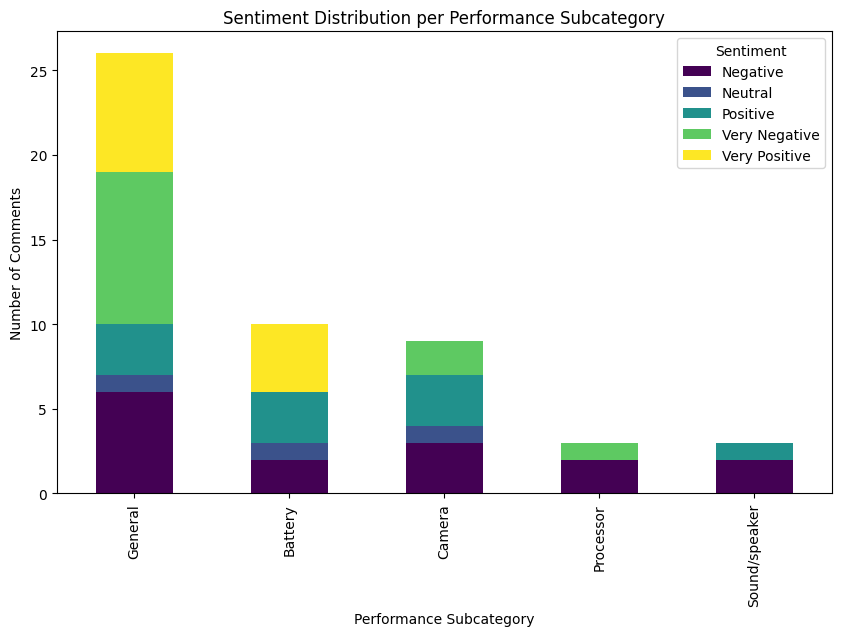

In [210]:
import pandas as pd
import matplotlib.pyplot as plt

# Pastikan kolom Sentiment_Bard ada
# performance_df = df[df['Theme_Label'] == 'Performance'].copy()
performance_df = df_merged[df_merged['Theme_Label'] == 'Performance'].copy()

# Buat pivot table: index=subkategori, columns=sentimen, values=count
sentiment_count_per_subcat = performance_df.pivot_table(
    index='Performance_Subcategory',
    columns='Sentiment_Bard',
    values='Comments',
    aggfunc='count',
    fill_value=0
)

# Hitung total review per subkategori
sentiment_count_per_subcat['Total'] = sentiment_count_per_subcat.sum(axis=1)

# Urutkan descending berdasarkan total
sentiment_count_sorted = sentiment_count_per_subcat.sort_values(by='Total', ascending=False)

# Hapus kolom Total sebelum plot
sentiment_count_sorted = sentiment_count_sorted.drop(columns='Total')

# Plot stacked bar chart
sentiment_count_sorted.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    colormap='viridis'
)

plt.xlabel('Performance Subcategory')
plt.ylabel('Number of Comments')
plt.title('Sentiment Distribution per Performance Subcategory')
plt.legend(title='Sentiment')
plt.show()


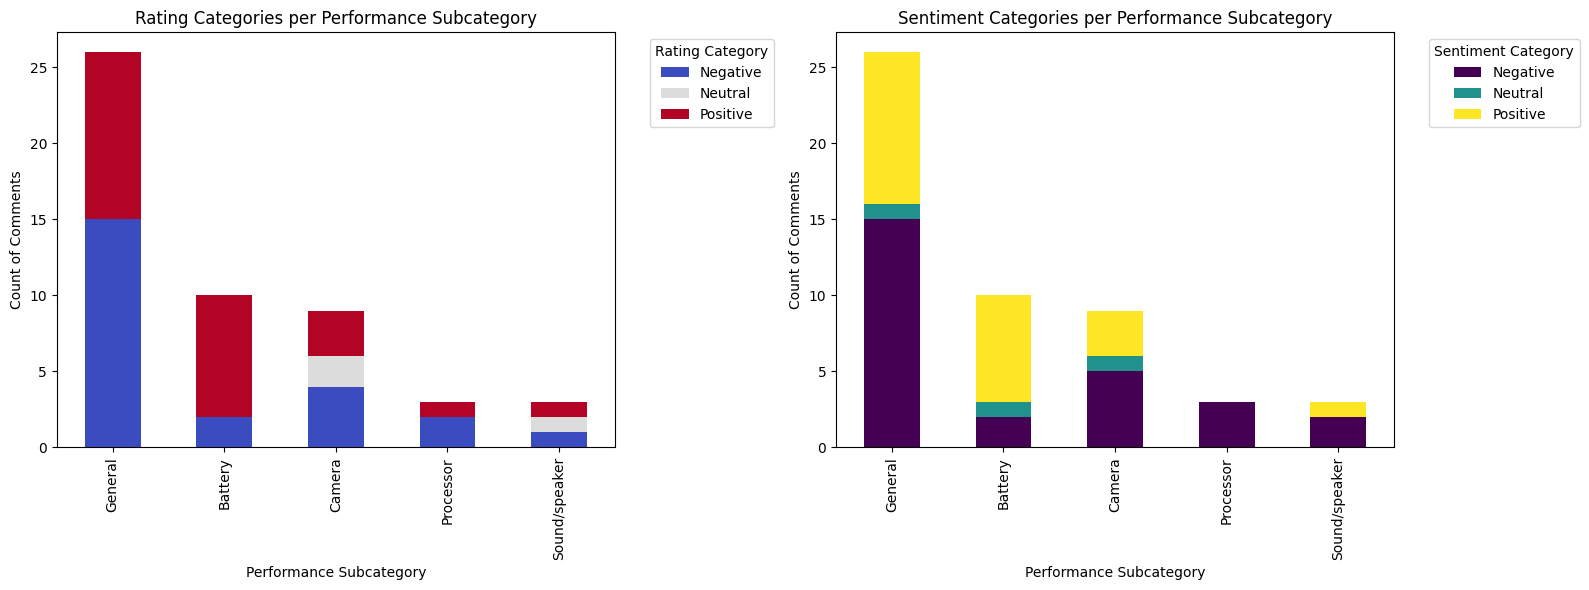

In [215]:
import matplotlib.pyplot as plt
import pandas as pd

# Filter data Performance saja
df_performance = df_merged[df_merged['Theme_Label'] == 'Performance'].copy()

# --- Mapping Rating ke kategori ---
def rating_category(r):
    if r in [1, 2]:
        return 'Negative'
    elif r == 3:
        return 'Neutral'
    elif r in [4, 5]:
        return 'Positive'
    else:
        return 'Neutral'

df_performance['Rating_Category'] = pd.to_numeric(df_performance['Rating'], errors='coerce').apply(rating_category)

# --- Mapping Sentiment_Bard ke kategori ---
def sentiment_category(s):
    if s in ['Very Negative', 'Negative']:
        return 'Negative'
    elif s == 'Neutral':
        return 'Neutral'
    elif s in ['Positive', 'Very Positive']:
        return 'Positive'
    else:
        return 'Neutral'

df_performance['Sentiment_Category'] = df_performance['Sentiment_Bard'].astype(str).apply(sentiment_category)

# Pivot table: jumlah komentar per Performance Subcategory dan Rating Categories
pivot_rating = df_performance.pivot_table(
    index='Performance_Subcategory',
    columns='Rating_Category',
    values='Comments',
    aggfunc='count',
    fill_value=0
)

# Pivot table: jumlah komentar per Performance Subcategory dan Sentiment Categories
pivot_sentiment = df_performance.pivot_table(
    index='Performance_Subcategory',
    columns='Sentiment_Category',
    values='Comments',
    aggfunc='count',
    fill_value=0
)

# Urutkan berdasarkan total komentar
order = pivot_rating.sum(axis=1).sort_values(ascending=False).index
pivot_rating_sorted = pivot_rating.loc[order]
pivot_sentiment_sorted = pivot_sentiment.loc[order]

# Plot stacked bar chart
fig, ax = plt.subplots(1, 2, figsize=(16,6))

pivot_rating_sorted.plot(kind='bar', stacked=True, ax=ax[0], colormap='coolwarm')
ax[0].set_title('Rating Categories per Performance Subcategory')
ax[0].set_ylabel('Count of Comments')
ax[0].set_xlabel('Performance Subcategory')
ax[0].legend(title='Rating Category', bbox_to_anchor=(1.05, 1), loc='upper left')

pivot_sentiment_sorted.plot(kind='bar', stacked=True, ax=ax[1], colormap='viridis')
ax[1].set_title('Sentiment Categories per Performance Subcategory')
ax[1].set_ylabel('Count of Comments')
ax[1].set_xlabel('Performance Subcategory')
ax[1].legend(title='Sentiment Category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


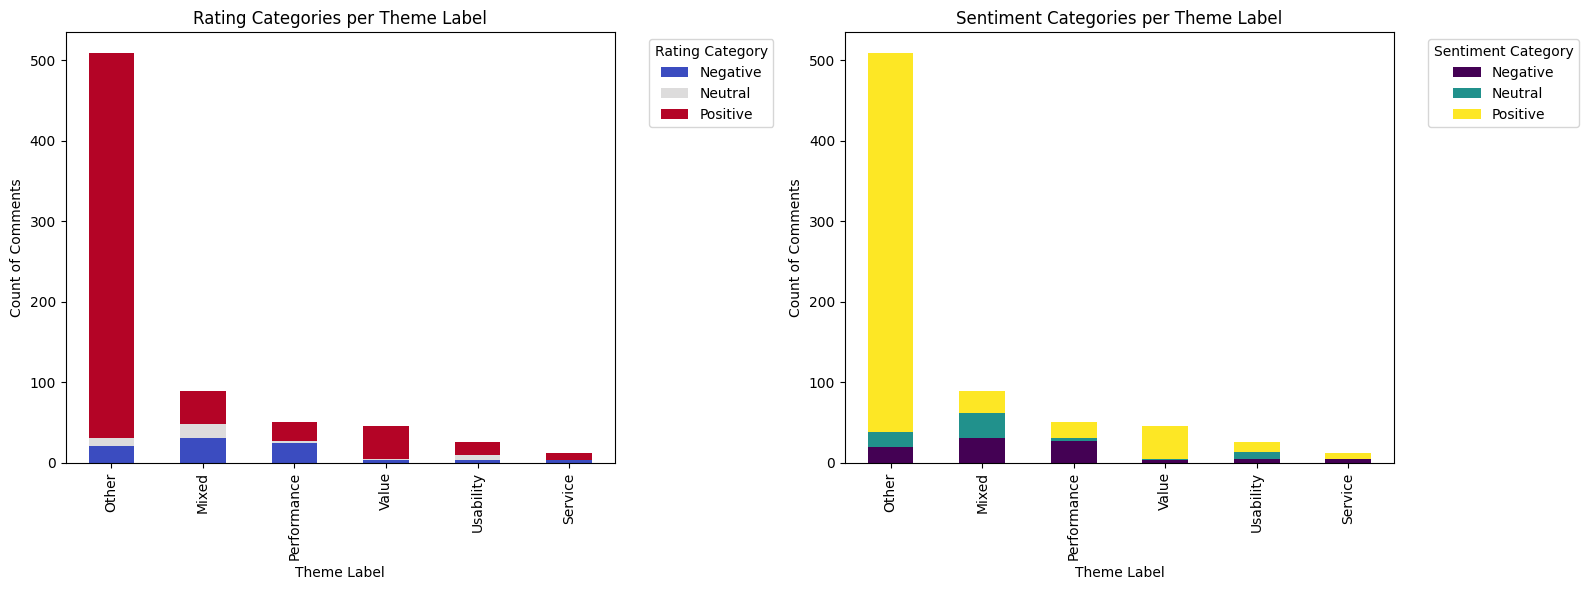

In [249]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Mapping Rating ke kategori ---
def rating_category(r):
    if r in [1, 2]:
        return 'Negative'
    elif r == 3:
        return 'Neutral'
    elif r in [4, 5]:
        return 'Positive'
    else:
        return 'Neutral'

df_merged['Rating_Category'] = pd.to_numeric(df_merged['Rating'], errors='coerce').apply(rating_category)

# --- Mapping Sentiment_Bard ke kategori ---
def sentiment_category(s):
    if s in ['Very Negative', 'Negative']:
        return 'Negative'
    elif s == 'Neutral':
        return 'Neutral'
    elif s in ['Positive', 'Very Positive']:
        return 'Positive'
    else:
        return 'Neutral'

df_merged['Sentiment_Category'] = df_merged['Sentiment_Bard'].astype(str).apply(sentiment_category)

# Pivot table: jumlah komentar per Theme_Label dan Rating Categories
pivot_rating = df_merged.pivot_table(
    index='Theme_Label',
    columns='Rating_Category',
    values='Comments',
    aggfunc='count',
    fill_value=0
)

# Pivot table: jumlah komentar per Theme_Label dan Sentiment Categories
pivot_sentiment = df_merged.pivot_table(
    index='Theme_Label',
    columns='Sentiment_Category',
    values='Comments',
    aggfunc='count',
    fill_value=0
)

# Urutkan berdasarkan total komentar
order = pivot_rating.sum(axis=1).sort_values(ascending=False).index
pivot_rating_sorted = pivot_rating.loc[order]
pivot_sentiment_sorted = pivot_sentiment.loc[order]

# Plot stacked bar chart
fig, ax = plt.subplots(1, 2, figsize=(16,6))

pivot_rating_sorted.plot(kind='bar', stacked=True, ax=ax[0], colormap='coolwarm')
ax[0].set_title('Rating Categories per Theme Label')
ax[0].set_ylabel('Count of Comments')
ax[0].set_xlabel('Theme Label')
ax[0].legend(title='Rating Category', bbox_to_anchor=(1.05, 1), loc='upper left')

pivot_sentiment_sorted.plot(kind='bar', stacked=True, ax=ax[1], colormap='viridis')
ax[1].set_title('Sentiment Categories per Theme Label')
ax[1].set_ylabel('Count of Comments')
ax[1].set_xlabel('Theme Label')
ax[1].legend(title='Sentiment Category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


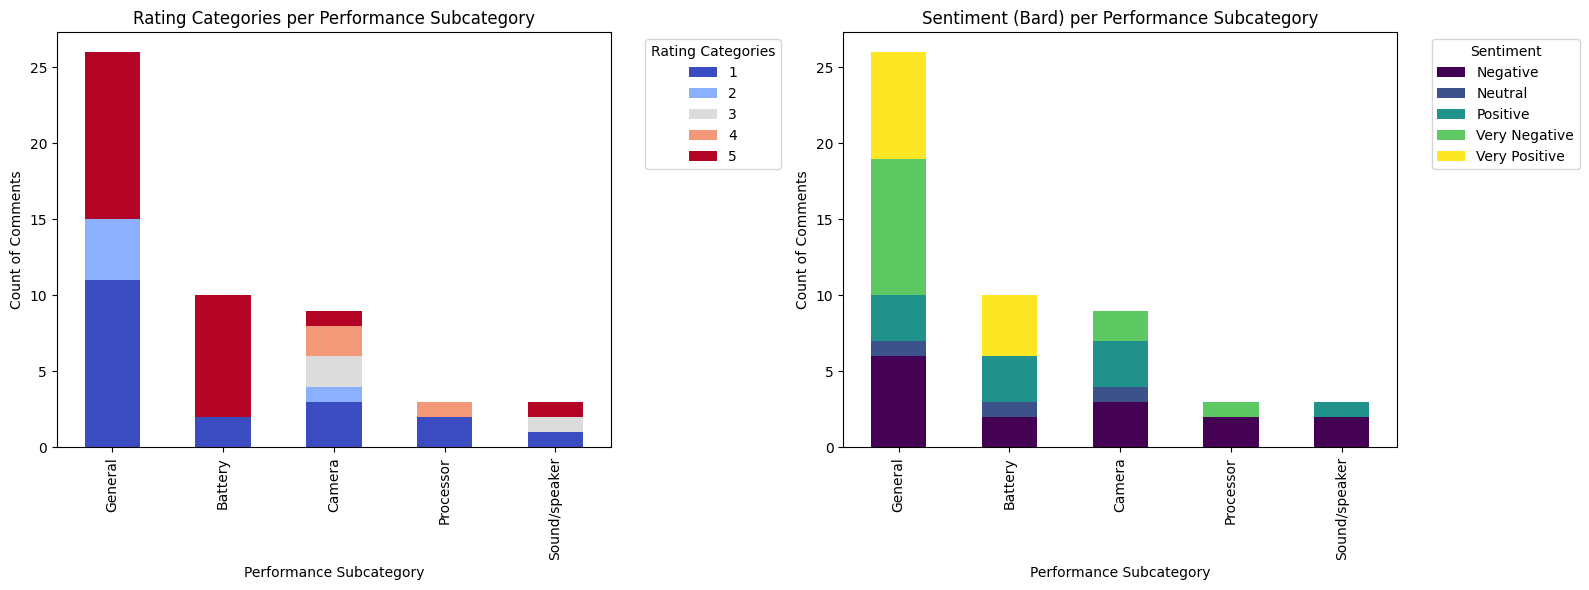

In [214]:
import matplotlib.pyplot as plt
import pandas as pd

# Filter data Performance saja
df_performance = df_merged[df_merged['Theme_Label'] == 'Performance'].copy()

# Pivot table: jumlah komentar per Performance Subcategory dan Rating
pivot_rating = df_performance.pivot_table(
    index='Performance_Subcategory',
    columns='Rating',
    values='Comments',
    aggfunc='count',
    fill_value=0
)

# Pivot table: jumlah komentar per Performance Subcategory dan Sentiment_Bard
pivot_sentiment = df_performance.pivot_table(
    index='Performance_Subcategory',
    columns='Sentiment_Bard',
    values='Comments',
    aggfunc='count',
    fill_value=0
)

# Hitung total komentar per subkategori dan urutkan descending
rating_order = pivot_rating.sum(axis=1).sort_values(ascending=False).index
pivot_rating_sorted = pivot_rating.loc[rating_order]
pivot_sentiment_sorted = pivot_sentiment.loc[rating_order]

# Plot stacked bar chart
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Rating Categories
pivot_rating_sorted.plot(kind='bar', stacked=True, ax=ax[0], colormap='coolwarm')
ax[0].set_title('Rating Categories per Performance Subcategory')
ax[0].set_ylabel('Count of Comments')
ax[0].set_xlabel('Performance Subcategory')
ax[0].legend(title='Rating Categories', bbox_to_anchor=(1.05, 1), loc='upper left')

# Sentiment Bard
pivot_sentiment_sorted.plot(kind='bar', stacked=True, ax=ax[1], colormap='viridis')
ax[1].set_title('Sentiment (Bard) per Performance Subcategory')
ax[1].set_ylabel('Count of Comments')
ax[1].set_xlabel('Performance Subcategory')
ax[1].legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [217]:
import pandas as pd

# Pastikan Rating numerik
df_merged['Rating'] = pd.to_numeric(df_merged['Rating'], errors='coerce')

# Buat kolom Rating_Category
def rating_category(r):
    if r in [1,2]:
        return 'Negative'
    elif r == 3:
        return 'Neutral'
    elif r in [4,5]:
        return 'Positive'
    else:
        return 'Neutral'

df_merged['Rating_Category'] = df_merged['Rating'].apply(rating_category)

# Buat kolom Sentiment_Category
def sentiment_category(s):
    if s in ['Very Negative', 'Negative']:
        return 'Negative'
    elif s == 'Neutral':
        return 'Neutral'
    elif s in ['Positive', 'Very Positive']:
        return 'Positive'
    else:
        return 'Neutral'

df_merged['Sentiment_Category'] = df_merged['Sentiment_Bard'].astype(str).apply(sentiment_category)


In [218]:
import pandas as pd

# Pastikan kolom sudah ada: Rating_Category dan Sentiment_Category
# Rating positive: 4–5 → Rating_Category='Positive'
# Sentiment positive: Positive & Very Positive → Sentiment_Category='Positive'

# Filter komentar positive berdasarkan Rating
df_rating_positive = df_merged[df_merged['Rating_Category'] == 'Positive']

# Hitung jumlah per Theme_Label
rating_positive_count = df_rating_positive.groupby('Theme_Label')['Comments'].count().reset_index()
rating_positive_count = rating_positive_count.rename(columns={'Comments':'Positive_Rating_Count'})

# Filter komentar positive berdasarkan Sentiment_Bard
df_sentiment_positive = df_merged[df_merged['Sentiment_Category'] == 'Positive']

# Hitung jumlah per Theme_Label
sentiment_positive_count = df_sentiment_positive.groupby('Theme_Label')['Comments'].count().reset_index()
sentiment_positive_count = sentiment_positive_count.rename(columns={'Comments':'Positive_Sentiment_Count'})

# Gabungkan hasil
positive_summary = pd.merge(rating_positive_count, sentiment_positive_count, on='Theme_Label', how='outer').fillna(0)

# Tampilkan
print(positive_summary)


   Theme_Label  Positive_Rating_Count  Positive_Sentiment_Count
0        Mixed                     41                        27
1        Other                    479                       471
2  Performance                     24                        21
3      Service                      9                         7
4    Usability                     17                        13
5        Value                     41                        41


In [227]:
import pandas as pd

# Pastikan kolom Rating_Category dan Sentiment_Category sudah ada
# Rating positive: 4–5 → Rating_Category='Positive'
# Sentiment positive: Positive & Very Positive → Sentiment_Category='Positive'

# Filter komentar positive berdasarkan Rating
df_rating_positive = df_merged[df_merged['Rating_Category'] == 'Positive'][['Theme_Label', 'Comments']]
df_rating_positive = df_rating_positive.rename(columns={'Comments':'Comments_Rating_Positive'})

# Gabungkan komentar per Theme_Label menjadi list
rating_pos_grouped = df_rating_positive.groupby('Theme_Label')['Comments_Rating_Positive'].apply(list).reset_index()

# Filter komentar positive berdasarkan Sentiment_Bard
df_sentiment_positive = df_merged[df_merged['Sentiment_Category'] == 'Positive'][['Theme_Label', 'Comments']]
df_sentiment_positive = df_sentiment_positive.rename(columns={'Comments':'Comments_Sentiment_Positive'})

# Gabungkan komentar per Theme_Label menjadi list
sentiment_pos_grouped = df_sentiment_positive.groupby('Theme_Label')['Comments_Sentiment_Positive'].apply(list).reset_index()

# Gabungkan kedua hasil
positive_comments_summary = pd.merge(rating_pos_grouped, sentiment_pos_grouped, on='Theme_Label', how='outer')

# Tampilkan
pd.set_option('display.max_colwidth', None)  # supaya seluruh komentar terlihat
print(positive_comments_summary)


   Theme_Label  \
0        Mixed   
1        Other   
2  Performance   
3      Service   
4    Usability   
5        Value   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [224]:
# Ganti escape sequence \r\n menjadi line break nyata
positive_comments['Comments_Rating_Positive'] = positive_comments['Comments_Rating_Positive'].str.replace(r'\\r\\n', '\n', regex=True)
positive_comments['Comments_Sentiment_Positive'] = positive_comments['Comments_Sentiment_Positive'].str.replace(r'\\r\\n', '\n', regex=True)


In [225]:
# Tampilkan komentar multi-line per cell
print(positive_comments.head(10).to_string(line_width=None))


  Theme_Label                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [226]:
# Contoh untuk komentar rating positif
for i, row in positive_comments.head(10).iterrows():
    print(f"Theme: {row['Theme_Label']}")
    print(row['Comments_Rating_Positive'].replace('\\r\\n','\n'))
    print('-'*50)


Theme: Mixed
Another Midrange killer Smartphone by Xiaomi

Major Highlights:
â€¢ The Redmi 6 Pro sports a 5.84-inch full-HD+ display with a notch
â€¢ Powered by the Qualcomm Snapdragon 625 SoC
â€¢ The phone is priced at Rs. 10,999 for the 3GB RAM variant (Start Point)
â€¢ Battery of 4000 mAh and its Durability
â€¢ The Tripple Slots
â€¢ Dual AI Camera

Well in Redmi 6 Series you will get 3 Different Smartphones with different specs, and from all of them, Redmi 6 pro is most powerful and advanced (as said by Redmi India in their launch event).

Xiaomi Redmi 6 Pro design:
Being the most premium phone of the new Redmi 6 family, the Redmi 6 Pro has been given somewhat better materials, in the form of a metal backplate. However, the overall design isnâ€™t too different from what weâ€™ve already seen from Xiaomi at around this price point. This is a fairly thick phone, and it's a bit hefty too, but itâ€™s manageable. The buttons have good feedback without being noisy, and on the left side, yo

In [2]:
import pandas as pd

df = pd.read_csv('../data/datasets/redmi6_with_theme.csv')

df

,Review Title,Customer name,Rating,Date,Category,Comments,Useful,Theme_Bard,Theme_Label,Performance_Subcategory
0,Another Midrange killer Smartphone by Xiaomi,Rishikumar Thakur,4,on 1 October 2018,Display,Another Midrange killer Smartphone by Xiaomi\r...,,The review comment should be classified as **M...,Mixed,NaN
1,vry small size mobile,Raza ji,3,on 15 September 2018,Others,All ok but vry small size mobile,7 people found this helpful,The review comment should be classified as **U...,Usability,NaN
2,Full display not working in all application.,Vaibhav Patel,3,on 18 September 2018,Others,Quite good,7 people found this helpful,The review comment should be classified as **O...,Other,NaN
3,Value for Money,Amazon Customer,5,on 28 September 2018,Display,Redmi has always have been the the king of bud...,2 people found this helpful,The review comment should be classified as **V...,Value,NaN
4,Not worth for the money,Sudhakaran Wadakkancheri,2,on 18 September 2018,Others,worst product from MI. I am a hardcore fan of ...,6 people found this helpful,The review comment should be classified as **O...,Other,NaN
...,...,...,...,...,...,...,...,...,...,...
275,"Cemera quality,face unlock most important in t...",Rahul,5,on 19 September 2018,Others,"I like This Phone, Awesome look and design.\r\...",NaN,The review comment should be classified as **U...,Usability,NaN
276,Mi is best phone,Sunil Soni,4,on 18 September 2018,Others,Product is avasome but invoice is note include...,NaN,The review comment should be classified as **M...,Mixed,NaN
277,Its a OK Phone,D.C.Padhi,3,on 15 September 2018,Battery,"Redmi Note4, Note5, now 6pro..It seems the old...",NaN,The review comment should be classified as **M...,Mixed,NaN
278,Redmi,Mahesh,5,on 21 September 2018,Others,I love mi,NaN,The review comment should be classified as **O...,Other,NaN


In [77]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


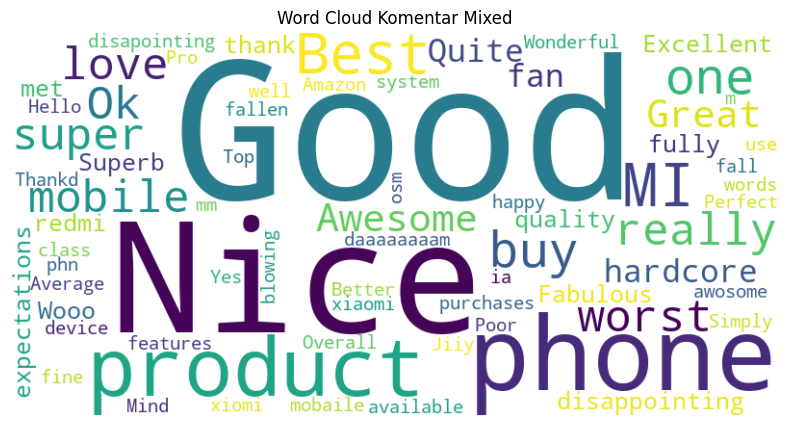

In [230]:
from wordcloud import WordCloud

# ambil semua komentar Mixed jadi satu string
text = " ".join(mixed_comments["Comments"].astype(str))

# buat wordcloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# tampilkan
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud Komentar Mixed")
plt.show()


In [231]:
from collections import Counter

for label in df_merged['Theme_Label'].unique():
    text = " ".join(df_merged[df_merged['Theme_Label']==label]["Comments"].astype(str))
    words = text.lower().split()
    most_common = Counter(words).most_common(10)
    print(f"Top 10 words in {label}:", most_common)


Top 10 words in Mixed: [('is', 235), ('the', 227), ('in', 173), ('and', 157), ('a', 128), ('this', 121), ('to', 111), ('camera', 107), ('good', 106), ('i', 98)]
Top 10 words in Usability: [('and', 12), ('the', 11), ('i', 9), ('mobile', 8), ('with', 8), ('but', 7), ('phone', 7), ('is', 6), ('quality', 6), ('all', 5)]
Top 10 words in Other: [('good', 355), ('nice', 78), ('phone', 25), ('product', 14), ('not', 10), ('ok', 10), ('do', 9), ('buy.', 9), ('mi.', 8), ('i', 8)]
Top 10 words in Value: [('is', 59), ('the', 55), ('and', 36), ('for', 33), ('good', 23), ('of', 21), ('in', 21), ('phone', 21), ('value', 21), ('this', 21)]
Top 10 words in Performance: [('and', 39), ('i', 33), ('of', 29), ('is', 25), ('not', 21), ('good', 21), ('these', 19), ('camera', 17), ('please', 15), ('quality', 15)]
Top 10 words in Service: [('delivery', 6), ('is', 6), ('nice', 4), ('product.', 4), ('guy', 4), ('also.', 4), ('in', 4), ('it', 4), ('i', 3), ('this', 3)]


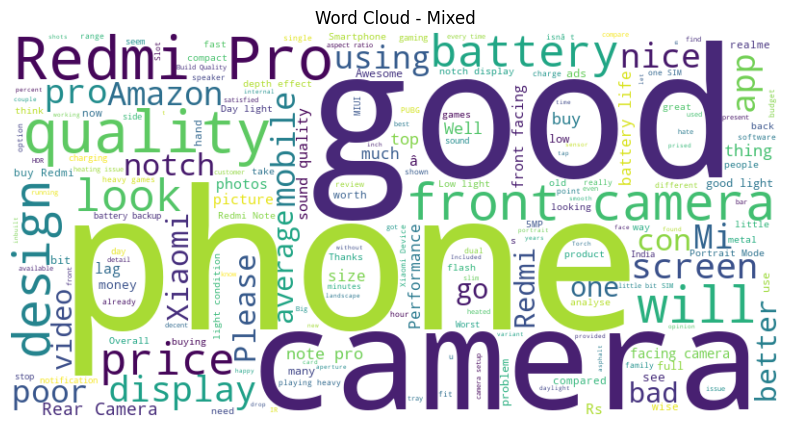

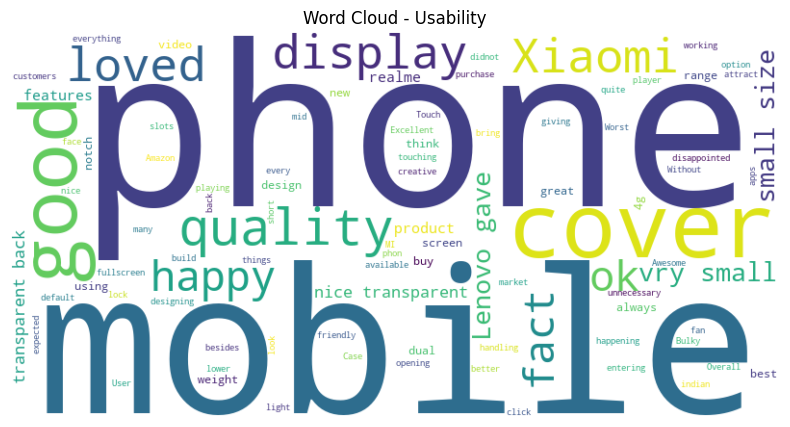

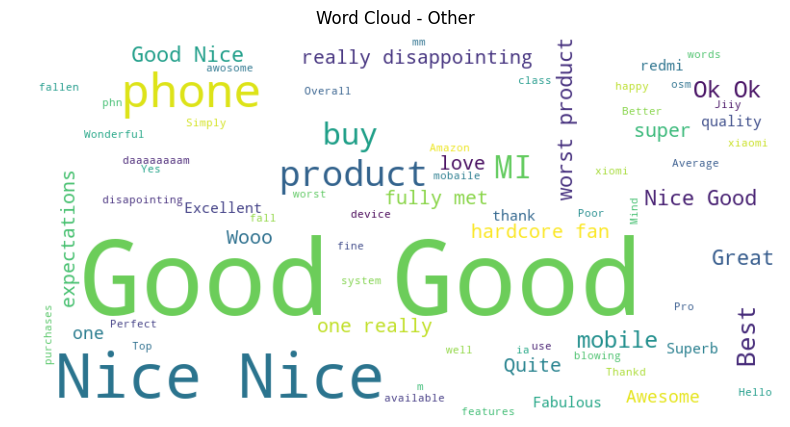

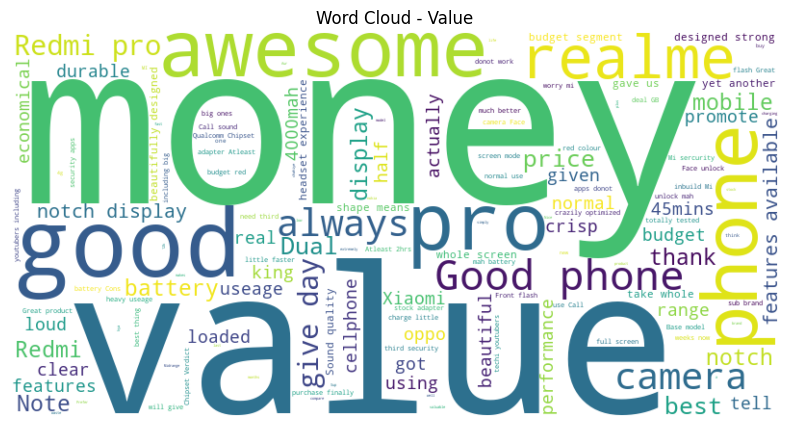

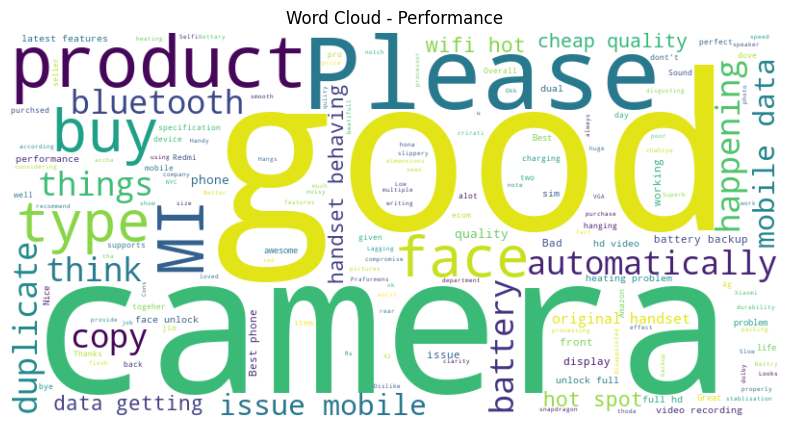

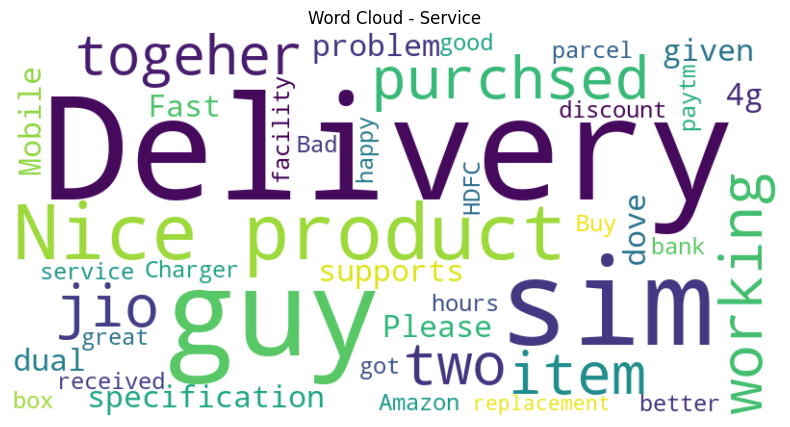

In [233]:
from wordcloud import WordCloud

for label in df_merged['Theme_Label'].unique():
    text = " ".join(df_merged[df_merged['Theme_Label']==label]["Comments"].astype(str))
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud - {label}")
    plt.show()


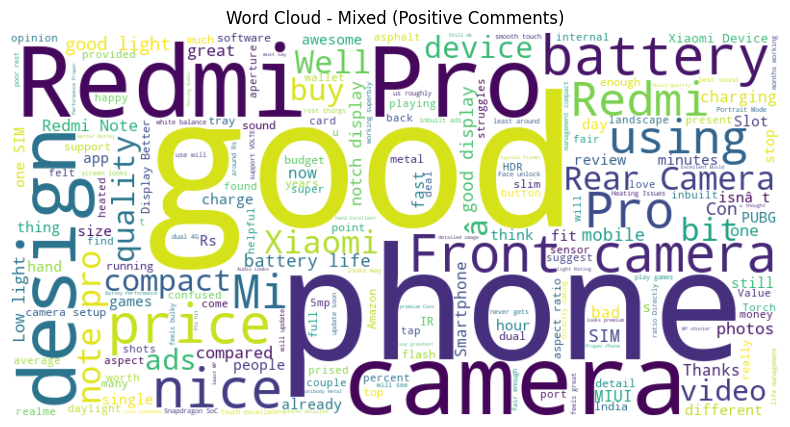

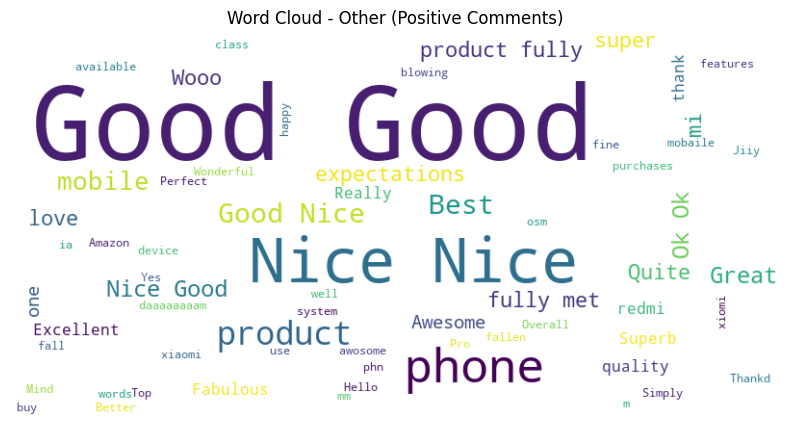

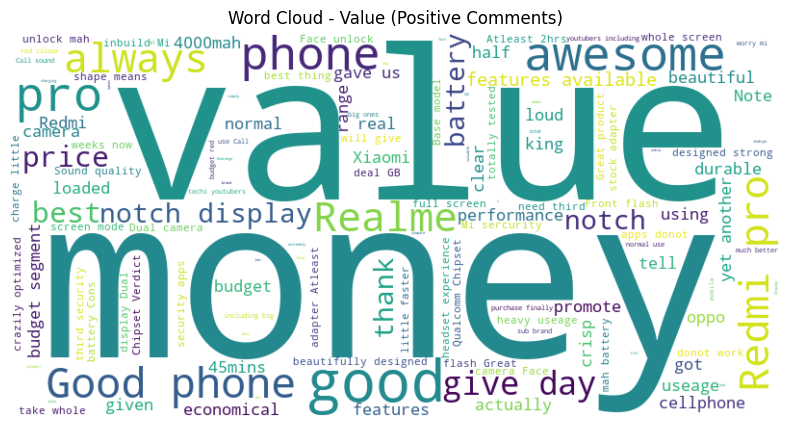

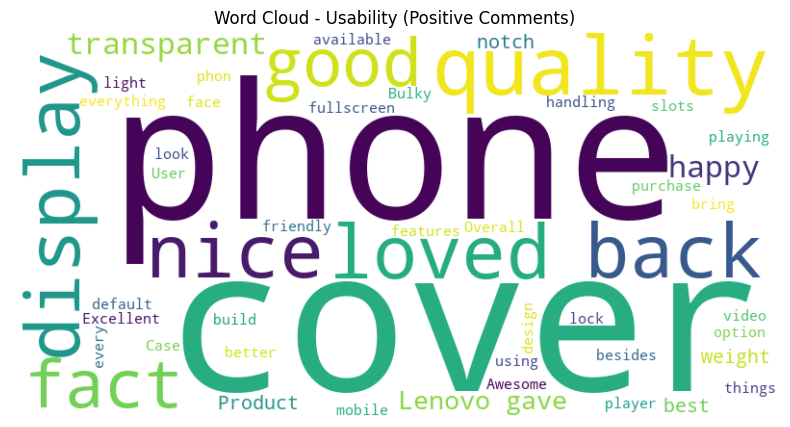

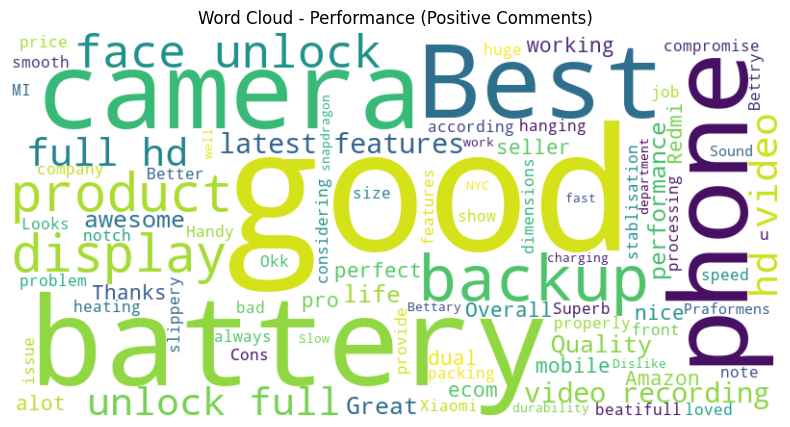

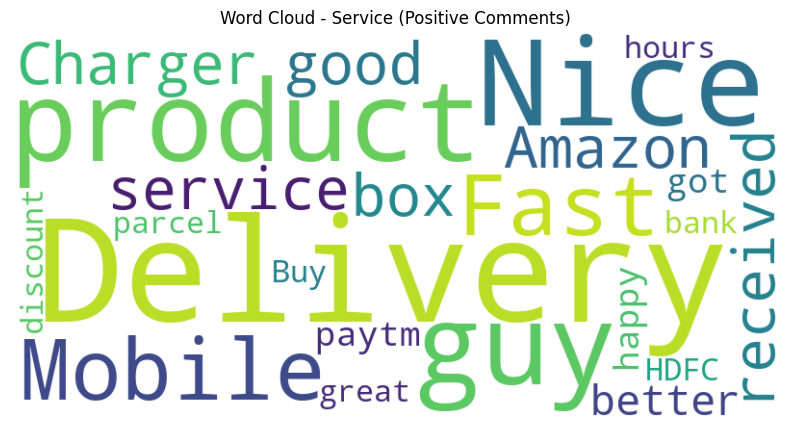

In [250]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pandas as pd

# Filter komentar positif (Rating 4-5 atau Sentiment Positive/Very Positive)
df_positive = df_merged[
    (df_merged['Rating_Category'] == 'Positive') | 
    (df_merged['Sentiment_Category'] == 'Positive')
].copy()

# Pastikan Theme_Label terisi
df_positive['Theme_Label'] = df_positive['Theme_Label'].fillna('Mixed')

# Generate word cloud per Theme_Label
for label in df_positive['Theme_Label'].unique():
    text = " ".join(df_positive[df_positive['Theme_Label'] == label]["Comments"].astype(str))
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud - {label} (Positive Comments)")
    plt.show()


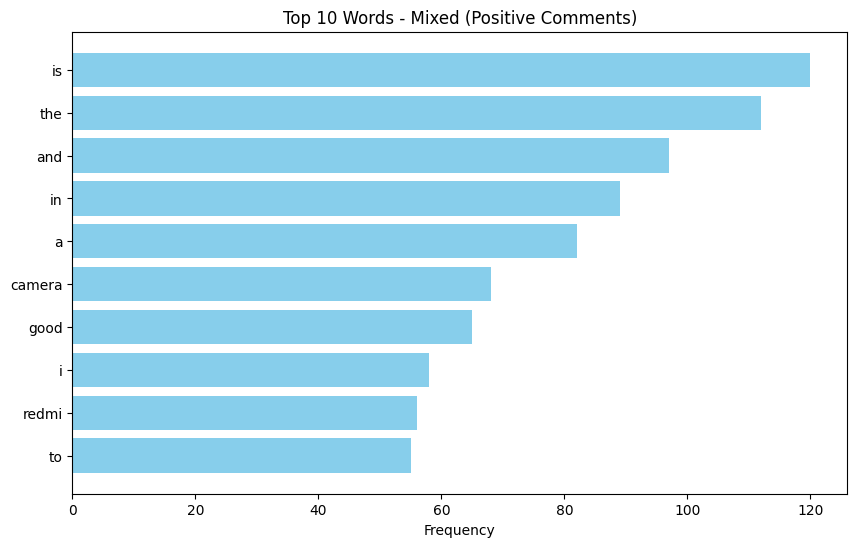

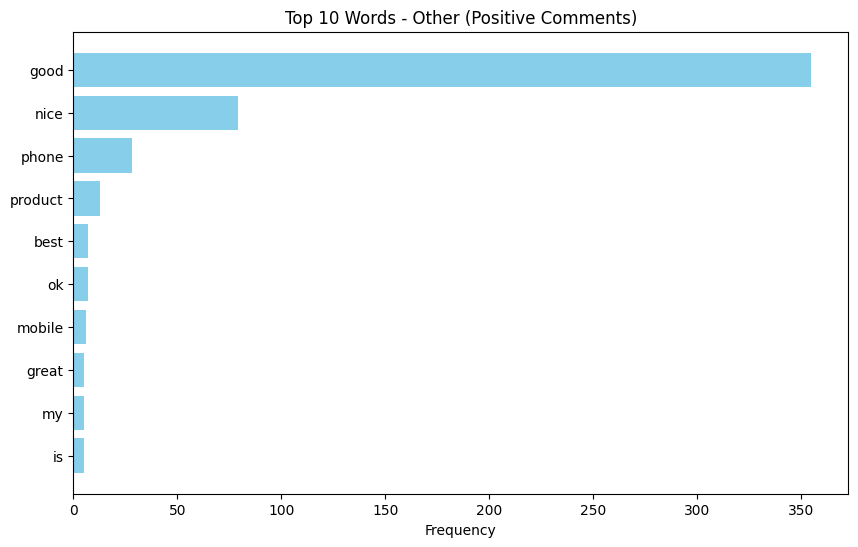

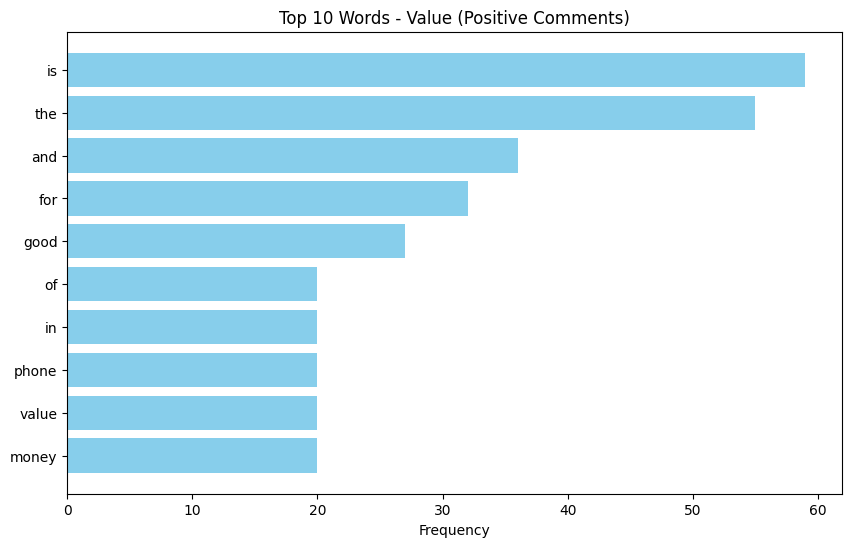

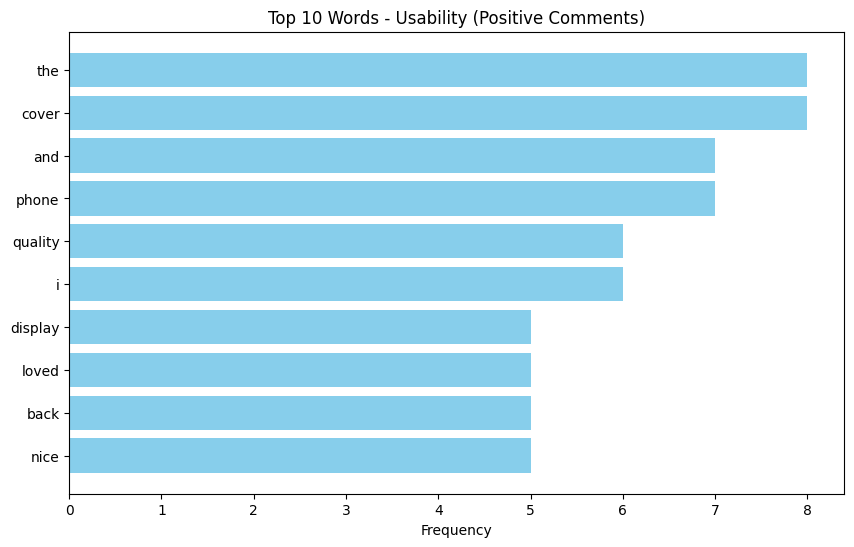

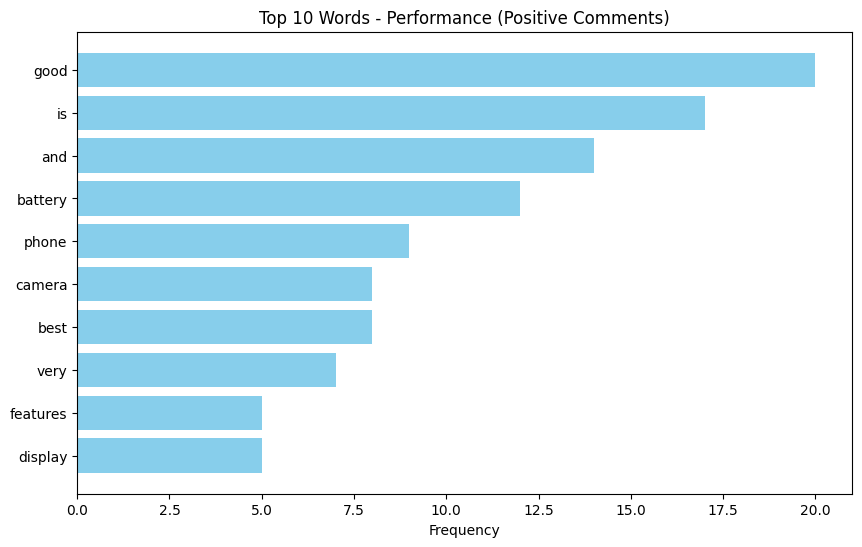

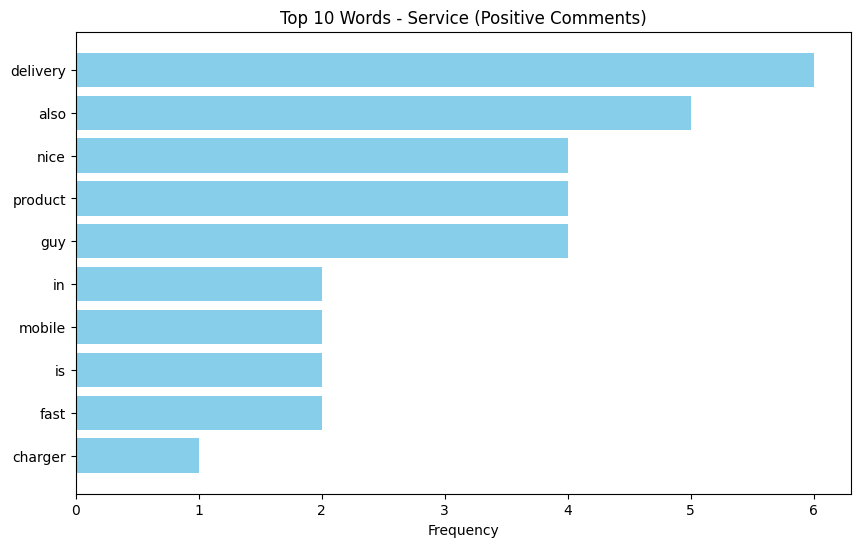

In [258]:
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
import re

# Filter komentar positif
df_positive = df_merged[
    (df_merged['Rating_Category'] == 'Positive') | 
    (df_merged['Sentiment_Category'] == 'Positive')
].copy()

# Pastikan Theme_Label terisi
df_positive['Theme_Label'] = df_positive['Theme_Label'].fillna('Mixed')

# Fungsi untuk membersihkan dan split kata
def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.lower().split()

# Generate horizontal bar chart top 10 kata per Theme_Label
for label in df_positive['Theme_Label'].unique():
    all_text = " ".join(df_positive[df_positive['Theme_Label'] == label]["Comments"].astype(str))
    words = clean_text(all_text)
    word_counts = Counter(words)
    top_words = word_counts.most_common(10)
    
    words, counts = zip(*top_words)
    
    plt.figure(figsize=(10,6))
    plt.barh(words, counts, color='skyblue')
    plt.title(f"Top 10 Words - {label} (Positive Comments)")
    plt.xlabel("Frequency")
    plt.gca().invert_yaxis()  # supaya kata terbanyak ada di atas
    plt.show()
